# 🔬 CIFAR-10-Initialized Models → SynthCIFAR Binary Benchmark

This notebook loads the requested **17 image classifiers**, starting from **CIFAR-10 checkpoints when available** and using the notebook's existing short scientific fine-tuning protocol only where a CIFAR-10 checkpoint is unavailable.

After the loading section, every model is **adapted to binary classification** on **SynthCIFAR** with classes:

- **real**
- **synthetic**

The full benchmark is designed for a **scientific article** and focuses on classification quality rather than runtime or hardware efficiency. The final evaluation includes:

- accuracy
- balanced accuracy
- precision, recall, specificity, F1
- ROC AUC and PR AUC
- MCC and Cohen's kappa
- log loss and Brier score
- ROC curves, PR curves, confusion matrices, calibration, and error analysis

> **Primary positive class:** `synthetic`


In [1]:
# Install required packages (run once)
import subprocess
import sys

packages = [
    "torch",
    "torchvision",
    "timm>=0.9.0",
    "transformers>=4.35.0",
    "datasets",
    "tqdm",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "pandas",
    "torchinfo",
    "fvcore",
    "huggingface_hub",
    "requests",
    "gdown",
]

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + packages)
print("✅ All packages installed.")


✅ All packages installed.


In [2]:
import gdown
import zipfile
import tarfile

# 1. Download the dataset
file_id = '1Yvq7OLFIyq6jjE2IqXd0-uNyhbmZOERS'
output_path = 'SynthCIFAR.tar' # Change to .tar.gz if applicable

gdown.download(id=file_id, output=output_path, quiet=False)

# 2. Extract directly to the current directory
print("Extracting...")

if output_path.endswith('.zip'):
    with zipfile.ZipFile(output_path, 'r') as zip_ref:
        zip_ref.extractall('.') 
        
elif output_path.endswith(('.tar', '.tar.gz', '.tgz')):
    with tarfile.open(output_path, 'r:*') as tar_ref:
        tar_ref.extractall('.')

print("Done! Files are in your current directory.")

Downloading...
From (original): https://drive.google.com/uc?id=1Yvq7OLFIyq6jjE2IqXd0-uNyhbmZOERS
From (redirected): https://drive.google.com/uc?id=1Yvq7OLFIyq6jjE2IqXd0-uNyhbmZOERS&confirm=t&uuid=03878c44-9447-4f92-bae2-98bf0375ca2d
To: /workspace/SynthCIFAR.tar
100%|██████████| 369M/369M [00:03<00:00, 101MB/s]  


Extracting...
Done! Files are in your current directory.


In [3]:
import gdown
import zipfile
import tarfile

# 1. Download the models
file_id = '1nVj9KPc96qzU3YXntt--qfu3wOTHykOA'
output_path = 'model_cache.zip' # Change to .tar.gz if applicable

gdown.download(id=file_id, output=output_path, quiet=False)

# 2. Extract directly to the current directory
print("Extracting...")

if output_path.endswith('.zip'):
    with zipfile.ZipFile(output_path, 'r') as zip_ref:
        zip_ref.extractall('.') 
        
elif output_path.endswith(('.tar', '.tar.gz', '.tgz')):
    with tarfile.open(output_path, 'r:*') as tar_ref:
        tar_ref.extractall('.')

print("Done! Files are in your current directory.")

Downloading...
From (original): https://drive.google.com/uc?id=1nVj9KPc96qzU3YXntt--qfu3wOTHykOA
From (redirected): https://drive.google.com/uc?id=1nVj9KPc96qzU3YXntt--qfu3wOTHykOA&confirm=t&uuid=1748d781-0e8b-4754-a7c2-d1c115d82746
To: /workspace/model_cache.zip
100%|██████████| 1.14G/1.14G [00:24<00:00, 46.5MB/s]


Extracting...
Done! Files are in your current directory.


In [4]:
!mv "Binary Classifiers" model_cache

mv: cannot overwrite 'model_cache/Binary Classifiers': File exists


In [5]:
import os
import sys
import json
import time
import math
import warnings
import shutil
import zipfile
import subprocess
from pathlib import Path
from copy import deepcopy
from collections import defaultdict
from contextlib import nullcontext

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import torchvision
import torchvision.transforms as T
import torchvision.models as tvm
from torchvision.datasets import ImageFolder

import timm
from transformers import AutoModelForImageClassification

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    cohen_kappa_score,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc,
    log_loss,
)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import label_binarize
from sklearn.exceptions import UndefinedMetricWarning
from torchinfo import summary as torchinfo_summary

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if device.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Base 10-class CIFAR-10 setup used for model loading / fallback pre-adaptation
CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]
NUM_CLASSES = 10

# Target binary SynthCIFAR setup
SYNTH_CLASSES = ["real", "synthetic"]
SYNTH_NUM_CLASSES = 2
POSITIVE_CLASS_NAME = "synthetic"

DATA_ROOT = Path("./data")
CACHE_DIR = Path("./model_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
HUYVNPHAN_REPO_DIR = CACHE_DIR / "PyTorch_CIFAR10"

# Update this path if needed
SYNTHCIFAR_ROOT = Path("./SynthCIFAR")

torch.manual_seed(42)
np.random.seed(42)

plt.style.use("seaborn-v0_8-whitegrid")
PALETTE = sns.color_palette("tab20", 20)

REQUESTED_MODELS = [
    "VGG16-BN",
    "MobileNetV2",
    "ResNet-50",
    "DenseNet-121",
    "DenseNet-169",
    "GoogLeNet",
    "InceptionV3",
    "ViT-Base/16",
    "Swin-Base",
    "ResNet-152",
    "DenseNet-201",
    "MNASNet-1.0",
    "EfficientNet-B0",
    "EfficientNetV2-S",
    "RegNetY-8GF",
    "ConvNeXt-Base",
    "ConvNeXtV2-Base",
]
print(f"Requested model count: {len(REQUESTED_MODELS)}")


Device : cuda
GPU    : NVIDIA RTX PRO 6000 Blackwell Workstation Edition
VRAM   : 102.0 GB
Requested model count: 17


## 📦 1 · Dataset Preparation

This notebook uses two datasets for two different purposes:

1. **CIFAR-10**  
   Used only where needed during the original loading section, especially for the short fallback fine-tuning path for architectures without a public CIFAR-10 checkpoint.

2. **SynthCIFAR**  
   Used for the **final binary task**:
   - `real`
   - `synthetic`

Expected SynthCIFAR structure:

```text
SynthCIFAR/
├── train/
│   ├── real/
│   └── synthetic/
└── test/
    ├── real/
    └── synthetic/
```

The training split is further divided into a **stratified train/validation split** for model selection.


In [6]:
# ── Transform pipelines ──────────────────────────────────────────────────────
# 32×32 pipelines for CIFAR-native models
tf_32 = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010]),
])

tf_32_huy = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2471, 0.2435, 0.2616]),
])

# 224×224 pipeline for transformers / torchvision / timm models
tf_224 = T.Compose([
    T.Resize(256, interpolation=T.InterpolationMode.BICUBIC),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

tf_train_224 = T.Compose([
    T.RandomCrop(32, padding=4),
    T.Resize(224, interpolation=T.InterpolationMode.BICUBIC),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# SynthCIFAR binary transforms
synth_tf_eval_32 = tf_32
synth_tf_eval_32_huy = tf_32_huy
synth_tf_eval_224 = tf_224

synth_tf_train_32 = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    T.ToTensor(),
    T.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010]),
])

synth_tf_train_32_huy = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    T.ToTensor(),
    T.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2471, 0.2435, 0.2616]),
])

synth_tf_train_224 = tf_train_224


class IndexedTransformDataset(Dataset):
    """Apply a transform to a selected set of indices from a torchvision-style dataset."""
    def __init__(self, base_dataset, indices, transform=None):
        self.base_dataset = base_dataset
        self.indices = np.asarray(indices, dtype=np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img, label = self.base_dataset[int(self.indices[idx])]
        if self.transform is not None:
            img = self.transform(img)
        return img, label


class ImageFolderFromBase(Dataset):
    """ImageFolder wrapper that keeps one raw base dataset and swaps transforms safely."""
    def __init__(self, base_dataset, indices=None, transform=None):
        self.base_dataset = base_dataset
        self.indices = np.arange(len(base_dataset)) if indices is None else np.asarray(indices, dtype=np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        base_idx = int(self.indices[idx])
        path, label = self.base_dataset.samples[base_idx]
        img = self.base_dataset.loader(path)
        if self.base_dataset.target_transform is not None:
            label = self.base_dataset.target_transform(label)
        if self.transform is not None:
            img = self.transform(img)
        return img, label


def stratified_split_indices(targets, val_ratio=0.10, seed=42):
    """Create a reproducible stratified train/validation split."""
    rng = np.random.RandomState(seed)
    targets = np.asarray(targets)
    train_idx, val_idx = [], []

    for cls in np.unique(targets):
        cls_idx = np.where(targets == cls)[0]
        rng.shuffle(cls_idx)
        n_val = max(1, int(round(len(cls_idx) * val_ratio)))
        val_idx.extend(cls_idx[:n_val].tolist())
        train_idx.extend(cls_idx[n_val:].tolist())

    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    return train_idx, val_idx


# ── CIFAR-10 data (for loading section / fallback initialization) ───────────
test_ds_32 = torchvision.datasets.CIFAR10(DATA_ROOT, train=False, download=True, transform=tf_32)
test_ds_32_huy = torchvision.datasets.CIFAR10(DATA_ROOT, train=False, download=True, transform=tf_32_huy)
test_ds_224 = torchvision.datasets.CIFAR10(DATA_ROOT, train=False, download=True, transform=tf_224)

base_train_raw = torchvision.datasets.CIFAR10(DATA_ROOT, train=True, download=True, transform=None)
cifar_train_idx, cifar_val_idx = stratified_split_indices(base_train_raw.targets, val_ratio=0.10, seed=42)

train_ds_224 = IndexedTransformDataset(base_train_raw, cifar_train_idx, transform=tf_train_224)
val_ds_224 = IndexedTransformDataset(base_train_raw, cifar_val_idx, transform=tf_224)

BS = 128 if device.type == "cuda" else 32
NW = 0 if device.type == "cuda" else 0
PIN = device.type == "cuda"

loader_32 = DataLoader(test_ds_32, batch_size=BS, shuffle=False, num_workers=NW, pin_memory=PIN)
loader_32_huy = DataLoader(test_ds_32_huy, batch_size=BS, shuffle=False, num_workers=NW, pin_memory=PIN)
loader_224 = DataLoader(test_ds_224, batch_size=BS, shuffle=False, num_workers=NW, pin_memory=PIN)
train_loader_224 = DataLoader(train_ds_224, batch_size=BS, shuffle=True, num_workers=NW, pin_memory=PIN)
val_loader_224 = DataLoader(val_ds_224, batch_size=BS, shuffle=False, num_workers=NW, pin_memory=PIN)

print(f"CIFAR-10 test images (32):            {len(test_ds_32)}")
print(f"CIFAR-10 test images (32, huy):       {len(test_ds_32_huy)}")
print(f"CIFAR-10 test images (224):           {len(test_ds_224)}")
print(f"CIFAR-10 fallback train split (224):  {len(train_ds_224)}")
print(f"CIFAR-10 fallback val split (224):    {len(val_ds_224)}")

# ── SynthCIFAR binary data ───────────────────────────────────────────────────
assert SYNTHCIFAR_ROOT.exists(), f"SynthCIFAR root not found: {SYNTHCIFAR_ROOT.resolve()}"
assert (SYNTHCIFAR_ROOT / "train").exists(), "Missing SynthCIFAR/train"
assert (SYNTHCIFAR_ROOT / "test").exists(), "Missing SynthCIFAR/test"

base_synth_train_raw = ImageFolder(SYNTHCIFAR_ROOT / "train", transform=None)
base_synth_test_raw = ImageFolder(SYNTHCIFAR_ROOT / "test", transform=None)

print(f"SynthCIFAR classes discovered in train: {base_synth_train_raw.classes}")
assert set(base_synth_train_raw.classes) == set(SYNTH_CLASSES), (
    "Expected SynthCIFAR classes {'real', 'synthetic'} "
    f"but got {base_synth_train_raw.classes}"
)
assert base_synth_train_raw.class_to_idx == base_synth_test_raw.class_to_idx, (
    "Train/test class mappings differ."
)

SYNTH_CLASSES = list(base_synth_train_raw.classes)
POSITIVE_CLASS_INDEX = base_synth_train_raw.class_to_idx[POSITIVE_CLASS_NAME]

synth_targets = [label for _, label in base_synth_train_raw.samples]
synth_train_idx, synth_val_idx = stratified_split_indices(synth_targets, val_ratio=0.10, seed=42)

synth_loaders = {
    "32": {
        "train": DataLoader(
            ImageFolderFromBase(base_synth_train_raw, synth_train_idx, transform=synth_tf_train_32),
            batch_size=BS, shuffle=True, num_workers=NW, pin_memory=PIN
        ),
        "val": DataLoader(
            ImageFolderFromBase(base_synth_train_raw, synth_val_idx, transform=synth_tf_eval_32),
            batch_size=BS, shuffle=False, num_workers=NW, pin_memory=PIN
        ),
        "test": DataLoader(
            ImageFolderFromBase(base_synth_test_raw, None, transform=synth_tf_eval_32),
            batch_size=BS, shuffle=False, num_workers=NW, pin_memory=PIN
        ),
    },
    "32_huy": {
        "train": DataLoader(
            ImageFolderFromBase(base_synth_train_raw, synth_train_idx, transform=synth_tf_train_32_huy),
            batch_size=BS, shuffle=True, num_workers=NW, pin_memory=PIN
        ),
        "val": DataLoader(
            ImageFolderFromBase(base_synth_train_raw, synth_val_idx, transform=synth_tf_eval_32_huy),
            batch_size=BS, shuffle=False, num_workers=NW, pin_memory=PIN
        ),
        "test": DataLoader(
            ImageFolderFromBase(base_synth_test_raw, None, transform=synth_tf_eval_32_huy),
            batch_size=BS, shuffle=False, num_workers=NW, pin_memory=PIN
        ),
    },
    "224": {
        "train": DataLoader(
            ImageFolderFromBase(base_synth_train_raw, synth_train_idx, transform=synth_tf_train_224),
            batch_size=BS, shuffle=True, num_workers=NW, pin_memory=PIN
        ),
        "val": DataLoader(
            ImageFolderFromBase(base_synth_train_raw, synth_val_idx, transform=synth_tf_eval_224),
            batch_size=BS, shuffle=False, num_workers=NW, pin_memory=PIN
        ),
        "test": DataLoader(
            ImageFolderFromBase(base_synth_test_raw, None, transform=synth_tf_eval_224),
            batch_size=BS, shuffle=False, num_workers=NW, pin_memory=PIN
        ),
    },
}

print(f"SynthCIFAR train images:              {len(base_synth_train_raw)}")
print(f"SynthCIFAR test images:               {len(base_synth_test_raw)}")
print(f"SynthCIFAR train split:               {len(synth_train_idx)}")
print(f"SynthCIFAR validation split:          {len(synth_val_idx)}")
print(f"Positive class ('{POSITIVE_CLASS_NAME}') index: {POSITIVE_CLASS_INDEX}")

for split_name, idxs in [("train", synth_train_idx), ("val", synth_val_idx)]:
    split_targets = np.asarray(synth_targets)[idxs]
    counts = {SYNTH_CLASSES[i]: int((split_targets == i).sum()) for i in range(len(SYNTH_CLASSES))}
    print(f"{split_name.capitalize()} class counts: {counts}")

test_targets = np.array([label for _, label in base_synth_test_raw.samples])
test_counts = {SYNTH_CLASSES[i]: int((test_targets == i).sum()) for i in range(len(SYNTH_CLASSES))}
print(f"Test class counts: {test_counts}")


CIFAR-10 test images (32):            10000
CIFAR-10 test images (32, huy):       10000
CIFAR-10 test images (224):           10000
CIFAR-10 fallback train split (224):  45000
CIFAR-10 fallback val split (224):    5000
SynthCIFAR classes discovered in train: ['real', 'synthetic']
SynthCIFAR train images:              100000
SynthCIFAR test images:               20000
SynthCIFAR train split:               90000
SynthCIFAR validation split:          10000
Positive class ('synthetic') index: 1
Train class counts: {'real': 45000, 'synthetic': 45000}
Val class counts: {'real': 5000, 'synthetic': 5000}
Test class counts: {'real': 10000, 'synthetic': 10000}


## 🔧 2 · Utility Functions

The utility section below includes:

- model registration helpers
- family-aware classifier-head replacement
- a generic short scientific fine-tuning protocol
- binary evaluation utilities for SynthCIFAR


In [7]:
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total / 1e6, trainable / 1e6


def estimate_macs(model, input_size=(1, 3, 224, 224)):
    try:
        s = torchinfo_summary(model, input_size=input_size, verbose=0, device=device, col_names=[])
        return s.total_mult_adds / 1e9
    except Exception:
        return float("nan")


def forward_logits(model, x):
    out = model(x)
    return out.logits if hasattr(out, "logits") else out


def score_predictions(labels, preds):
    return {
        "accuracy": accuracy_score(labels, preds) * 100,
        "balanced_accuracy": balanced_accuracy_score(labels, preds) * 100,
        "f1_macro": precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)[2] * 100,
    }


def run_epoch(model, loader, optimizer=None, criterion=None, scaler=None, desc="epoch"):
    """
    Run one epoch.
    If optimizer is None, runs in evaluation mode and returns validation statistics.
    """
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    all_preds, all_labels = [], []

    amp_enabled = (device.type == "cuda") and ("convnextv2" not in model.__class__.__name__.lower())
    autocast_ctx = torch.cuda.amp.autocast if amp_enabled else nullcontext

    for imgs, labels in tqdm(loader, desc=desc, leave=False):
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with autocast_ctx() if not amp_enabled else autocast_ctx(enabled=True):
            logits = forward_logits(model, imgs).float()

            if torch.isnan(logits).any() or torch.isinf(logits).any():
                raise RuntimeError(f"{desc}: invalid logits detected")

            loss = criterion(logits, labels) if criterion is not None else None

            if loss is not None and (torch.isnan(loss) or torch.isinf(loss)):
                raise RuntimeError(f"{desc}: invalid loss detected")

        if is_train:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
            scaler.step(optimizer)
            scaler.update()

        total_loss += (0.0 if loss is None else loss.item() * labels.size(0))
        preds = logits.argmax(1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    all_preds = np.asarray(all_preds)
    all_labels = np.asarray(all_labels)
    stats = score_predictions(all_labels, all_preds)
    stats["loss"] = total_loss / max(1, len(loader.dataset))
    return stats


def build_confusion_metrics_df(cm, class_names):
    rows = []
    total = cm.sum()
    for i, cls_name in enumerate(class_names):
        tp = int(cm[i, i])
        fn = int(cm[i, :].sum() - tp)
        fp = int(cm[:, i].sum() - tp)
        tn = int(total - tp - fn - fp)

        sensitivity = 0.0 if (tp + fn) == 0 else tp / (tp + fn)
        specificity = 0.0 if (tn + fp) == 0 else tn / (tn + fp)
        precision = 0.0 if (tp + fp) == 0 else tp / (tp + fp)
        npv = 0.0 if (tn + fn) == 0 else tn / (tn + fn)
        fpr = 0.0 if (fp + tn) == 0 else fp / (fp + tn)
        fnr = 0.0 if (fn + tp) == 0 else fn / (fn + tp)

        rows.append({
            "Class": cls_name,
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "TN": tn,
            "Precision (%)": precision * 100,
            "Recall / Sensitivity (%)": sensitivity * 100,
            "Specificity (%)": specificity * 100,
            "NPV (%)": npv * 100,
            "FPR (%)": fpr * 100,
            "FNR (%)": fnr * 100,
            "Support": int(cm[i, :].sum()),
        })
    return pd.DataFrame(rows)


def infer_model_family(model):
    name = model.__class__.__name__.lower()
    if any(k in name for k in ["vit", "deit", "beit"]):
        return "vit"
    if "swin" in name:
        return "swin"
    if "convnextv2" in name:
        return "convnextv2"
    if "convnext" in name:
        return "convnext"
    if "mnasnet" in name:
        return "mnasnet"
    if "efficientnetv2" in name:
        return "efficientnetv2"
    if "efficientnet" in name:
        return "efficientnet"
    if "regnet" in name:
        return "regnet"
    if "densenet" in name:
        return "densenet"
    if "resnet" in name:
        return "resnet"
    if "googlenet" in name:
        return "googlenet"
    if "inception" in name:
        return "inception"
    return "generic"


def set_trainable_scope(model, head_only=False):
    for p in model.parameters():
        p.requires_grad_(True)

    if not head_only:
        return

    head_keywords = ("classifier", "fc", "head", "heads")
    for name, p in model.named_parameters():
        if not any(k in name.lower() for k in head_keywords):
            p.requires_grad_(False)


def replace_head(model, num_classes=10):
    if hasattr(model, "reset_classifier"):
        model.reset_classifier(num_classes)
        return model
    if hasattr(model, "fc") and isinstance(model.fc, nn.Linear):
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        return model
    if hasattr(model, "classifier"):
        c = model.classifier
        if isinstance(c, nn.Linear):
            model.classifier = nn.Linear(c.in_features, num_classes)
            return model
        if isinstance(c, nn.Sequential):
            layers = list(c.children())
            for idx in range(len(layers) - 1, -1, -1):
                if isinstance(layers[idx], nn.Linear):
                    layers[idx] = nn.Linear(layers[idx].in_features, num_classes)
                    model.classifier = nn.Sequential(*layers)
                    return model
    if hasattr(model, "head") and isinstance(model.head, nn.Linear):
        model.head = nn.Linear(model.head.in_features, num_classes)
        return model
    if hasattr(model, "heads") and hasattr(model.heads, "head") and isinstance(model.heads.head, nn.Linear):
        model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)
        return model
    raise ValueError(f"Could not replace classifier head for model type: {type(model)}")


def finetune(
    model,
    train_loader,
    val_loader,
    cache_name,
    head_epochs=2,
    full_epochs=8,
    lr_head=1e-3,
    lr_full=1e-4,
    weight_decay=5e-5,
    patience=3,
    family=None,
    label_smoothing=0.05,
    selection_metric_name="0.7 * val_macro_F1 + 0.3 * val_balanced_accuracy",
):
    """Generic family-aware short scientific fine-tuning protocol."""
    family = family or infer_model_family(model)

    family_cfg = {
        "vit":        dict(head_epochs=max(head_epochs, 3), full_epochs=max(full_epochs, 12), lr_head=min(lr_head, 8e-4), lr_full=min(lr_full, 5e-5), weight_decay=max(weight_decay, 1e-4), patience=max(patience, 4)),
        "swin":       dict(head_epochs=max(head_epochs, 3), full_epochs=max(full_epochs, 12), lr_head=min(lr_head, 8e-4), lr_full=min(lr_full, 5e-5), weight_decay=max(weight_decay, 1e-4), patience=max(patience, 4)),
        "convnext":   dict(head_epochs=max(head_epochs, 3), full_epochs=max(full_epochs, 12), lr_head=min(lr_head, 1e-3), lr_full=min(lr_full, 7e-5), weight_decay=max(weight_decay, 1e-4), patience=max(patience, 4)),
       # "convnextv2": dict(head_epochs=max(head_epochs, 3), full_epochs=max(full_epochs, 12), lr_head=min(lr_head, 1e-3), lr_full=min(lr_full, 7e-5), weight_decay=max(weight_decay, 1e-4), patience=max(patience, 4)),
        "convnextv2": dict(head_epochs=max(head_epochs, 2), full_epochs=max(full_epochs, 8),  lr_head=min(lr_head, 5e-4), lr_full=min(lr_full, 1e-5), weight_decay=max(weight_decay, 1e-4), patience=max(patience, 4)),
        "mnasnet":    dict(head_epochs=max(head_epochs, 3), full_epochs=max(full_epochs, 10), lr_head=min(lr_head, 1e-3), lr_full=min(lr_full, 8e-5), weight_decay=max(weight_decay, 1e-4), patience=max(patience, 4)),
        "generic":    dict(head_epochs=head_epochs, full_epochs=full_epochs, lr_head=lr_head, lr_full=lr_full, weight_decay=weight_decay, patience=patience),
    }
    cfg = family_cfg.get(family, family_cfg["generic"])
    head_epochs = cfg["head_epochs"]
    full_epochs = cfg["full_epochs"]
    lr_head = cfg["lr_head"]
    lr_full = cfg["lr_full"]
    weight_decay = cfg["weight_decay"]
    patience = cfg["patience"]

    cache_path = CACHE_DIR / cache_name
    if cache_path.exists():
        print(f"  Loading cached fine-tuned weights: {cache_path}")
        ckpt = torch.load(cache_path, map_location=device)
        if isinstance(ckpt, dict) and "state_dict" in ckpt:
            model.load_state_dict(ckpt["state_dict"])
        else:
            model.load_state_dict(ckpt)
        model.eval()
        return model

    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
    best_state = deepcopy(model.state_dict())
    best_score = -float("inf")
    history = []

    stage_plan = [
        ("head-only warm-up", head_epochs, True, lr_head),
        ("full fine-tuning", full_epochs, False, lr_full),
    ]

    print(
        f"  Fine-tuning [{family}] with {head_epochs} head epoch(s) + "
        f"up to {full_epochs} full epoch(s); patience={patience}; "
        f"lr_head={lr_head:.1e}; lr_full={lr_full:.1e}"
    )

    for stage_name, n_epochs, head_only, lr in stage_plan:
        if n_epochs <= 0:
            continue

        set_trainable_scope(model, head_only=head_only)
        trainable_params = [p for p in model.parameters() if p.requires_grad]
        optimizer = torch.optim.AdamW(trainable_params, lr=lr, weight_decay=weight_decay)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="max", factor=0.5, patience=1, min_lr=1e-6
        )
        stale_epochs = 0

        for ep in range(1, n_epochs + 1):
            tr = run_epoch(
                model, train_loader,
                optimizer=optimizer,
                criterion=criterion,
                scaler=scaler,
                desc=f"{cache_name} | {stage_name} | train {ep}/{n_epochs}",
            )
            va = run_epoch(
                model, val_loader,
                optimizer=None,
                criterion=criterion,
                scaler=scaler,
                desc=f"{cache_name} | {stage_name} | val {ep}/{n_epochs}",
            )

            composite_score = 0.7 * va["f1_macro"] + 0.3 * va["balanced_accuracy"]
            improved = composite_score > (best_score + 1e-5)

            history.append({
                "stage": stage_name,
                "epoch_in_stage": ep,
                "train_loss": tr["loss"],
                "train_acc": tr["accuracy"],
                "train_f1_macro": tr["f1_macro"],
                "val_loss": va["loss"],
                "val_acc": va["accuracy"],
                "val_balanced_accuracy": va["balanced_accuracy"],
                "val_f1_macro": va["f1_macro"],
                "selection_score": composite_score,
                "lr": optimizer.param_groups[0]["lr"],
            })

            print(
                f"  [{stage_name:18s}] ep {ep:02d}/{n_epochs} | "
                f"train loss={tr['loss']:.4f}, acc={tr['accuracy']:.2f}%, F1m={tr['f1_macro']:.2f}% | "
                f"val loss={va['loss']:.4f}, acc={va['accuracy']:.2f}%, "
                f"bal_acc={va['balanced_accuracy']:.2f}%, F1m={va['f1_macro']:.2f}%"
            )

            if improved:
                best_score = composite_score
                best_state = deepcopy(model.state_dict())
                stale_epochs = 0
            else:
                stale_epochs += 1

            scheduler.step(composite_score)

            if stale_epochs >= patience:
                print(f"  Early stopping triggered in {stage_name}.")
                break

    model.load_state_dict(best_state)
    torch.save(
        {
            "state_dict": model.state_dict(),
            "history": history,
            "protocol": {
                "family": family,
                "head_epochs": head_epochs,
                "full_epochs": full_epochs,
                "lr_head": lr_head,
                "lr_full": lr_full,
                "weight_decay": weight_decay,
                "patience": patience,
                "selection_metric": selection_metric_name,
            },
        },
        cache_path,
    )
    print(f"  ✅ Saved best validation-selected checkpoint to {cache_path}")
    model.eval()
    return model


@torch.no_grad()
def evaluate_binary(model, loader, model_name="model", class_names=None, positive_index=1, desc=None):
    """Binary evaluation for SynthCIFAR with scientific-report metrics."""
    class_names = class_names or SYNTH_CLASSES
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    for imgs, labels in tqdm(loader, desc=desc or f"Eval {model_name}", leave=False):
        imgs = imgs.to(device, non_blocking=True)
        logits = forward_logits(model, imgs)
        probs = F.softmax(logits, dim=1)
        preds = logits.argmax(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    all_preds = np.asarray(all_preds)
    all_labels = np.asarray(all_labels)
    all_probs = np.asarray(all_probs)

    pos_probs = all_probs[:, positive_index]
    cm = confusion_matrix(all_labels, all_preds, labels=np.arange(len(class_names)))
    cm_norm = cm.astype(np.float64) / np.clip(cm.sum(axis=1, keepdims=True), a_min=1, a_max=None) * 100.0

    acc = accuracy_score(all_labels, all_preds) * 100
    bal_acc = balanced_accuracy_score(all_labels, all_preds) * 100

    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro", zero_division=0
    )
    prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="weighted", zero_division=0
    )
    cls_prec, cls_rec, cls_f1, cls_support = precision_recall_fscore_support(
        all_labels, all_preds, average=None, labels=np.arange(len(class_names)), zero_division=0
    )

    confusion_metrics_df = build_confusion_metrics_df(cm, class_names)

    # Positive-class oriented metrics (synthetic = positive)
    positive_row = int(positive_index)
    precision_pos = cls_prec[positive_row] * 100
    recall_pos = cls_rec[positive_row] * 100
    f1_pos = cls_f1[positive_row] * 100
    specificity = float(confusion_metrics_df.loc[positive_row, "Specificity (%)"])
    npv = float(confusion_metrics_df.loc[positive_row, "NPV (%)"])
    fpr = float(confusion_metrics_df.loc[positive_row, "FPR (%)"])
    fnr = float(confusion_metrics_df.loc[positive_row, "FNR (%)"])

    roc_auc = roc_auc_score(all_labels, pos_probs) * 100
    pr_auc = average_precision_score(all_labels, pos_probs) * 100
    fpr_curve, tpr_curve, _ = roc_curve(all_labels, pos_probs, pos_label=positive_index)
    pr_prec_curve, pr_rec_curve, _ = precision_recall_curve(all_labels, pos_probs, pos_label=positive_index)

    mcc = matthews_corrcoef(all_labels, all_preds)
    kappa = cohen_kappa_score(all_labels, all_preds)
    ll = log_loss(all_labels, all_probs, labels=np.arange(len(class_names)))
    y_true_pos = (all_labels == positive_index).astype(int)
    brier = np.mean((pos_probs - y_true_pos) ** 2)

    calib_true, calib_pred = calibration_curve(y_true_pos, pos_probs, n_bins=10, strategy="quantile")

    per_class_rows = []
    for i, cls_name in enumerate(class_names):
        per_class_rows.append({
            "Class": cls_name,
            "Precision (%)": cls_prec[i] * 100,
            "Recall / Sensitivity (%)": cls_rec[i] * 100,
            "Specificity (%)": float(confusion_metrics_df.loc[i, "Specificity (%)"]),
            "NPV (%)": float(confusion_metrics_df.loc[i, "NPV (%)"]),
            "FPR (%)": float(confusion_metrics_df.loc[i, "FPR (%)"]),
            "FNR (%)": float(confusion_metrics_df.loc[i, "FNR (%)"]),
            "F1 Score (%)": cls_f1[i] * 100,
            "Support": int(cls_support[i]),
        })
    per_class_df = pd.DataFrame(per_class_rows)

    class_report = classification_report(
        all_labels, all_preds, target_names=class_names, digits=4, zero_division=0
    )

    return dict(
        accuracy=acc,
        balanced_accuracy=bal_acc,
        precision_macro=prec_macro * 100,
        recall_macro=rec_macro * 100,
        f1_macro=f1_macro * 100,
        precision_weighted=prec_weighted * 100,
        recall_weighted=rec_weighted * 100,
        f1_weighted=f1_weighted * 100,
        precision_positive=precision_pos,
        recall_positive=recall_pos,
        specificity=specificity,
        npv=npv,
        fpr=fpr,
        fnr=fnr,
        f1_positive=f1_pos,
        roc_auc=roc_auc,
        pr_auc=pr_auc,
        mcc=mcc,
        cohen_kappa=kappa,
        log_loss=ll,
        brier_score=brier,
        confusion_matrix=cm,
        confusion_matrix_norm=cm_norm,
        confusion_metrics=confusion_metrics_df,
        per_class_metrics=per_class_df,
        class_report=class_report,
        preds=all_preds,
        labels=all_labels,
        probs=all_probs,
        positive_probs=pos_probs,
        roc_curve=(fpr_curve, tpr_curve),
        pr_curve=(pr_rec_curve, pr_prec_curve),
        calibration_curve=(calib_pred, calib_true),
    )


## 🤖 3 · Model Loading

The registry is restricted to the requested **17 architectures**:

- VGG16-BN
- MobileNetV2
- ResNet-50
- DenseNet-121
- DenseNet-169
- GoogLeNet
- InceptionV3
- ViT-Base/16
- Swin-Base
- ResNet-152
- DenseNet-201
- MNASNet-1.0
- EfficientNet-B0
- EfficientNetV2-S
- RegNetY-8GF
- ConvNeXt-Base
- ConvNeXtV2-Base


In [8]:
MODEL_REGISTRY = {}

def register(name, model, loader_key, source, input_hw=224):
    p, _ = count_params(model)
    macs = estimate_macs(model, input_size=(1, 3, input_hw, input_hw))
    MODEL_REGISTRY[name] = {
        "model": model,
        "loader": loader_key,
        "source": source,
        "params_M": round(p, 2),
        "macs_G": round(macs, 3),
    }
    print(f"  ✅ {name:20s} | {p:7.1f}M params | {macs:.2f} GMACs | src: {source}")

print("Registry ready.")


Registry ready.


### 3.1 chenyaofo/pytorch-cifar-models *(CIFAR-10 native, 32×32)*


In [9]:
CHENYAOFO_REPO = "chenyaofo/pytorch-cifar-models"
CHENYAOFO_SRC = "torch.hub / chenyaofo (CIFAR-10 native)"

chenyaofo_models = {
    "VGG19-BN": "cifar10_vgg19_bn",
    "MobileNetV2": "cifar10_mobilenetv2_x1_0",
}

for display_name, hub_name in chenyaofo_models.items():
    try:
        m = torch.hub.load(CHENYAOFO_REPO, hub_name, pretrained=True, trust_repo=True, verbose=False)
        m = m.to(device).eval()
        register(display_name, m, "32", CHENYAOFO_SRC, input_hw=32)
    except Exception as e:
        print(f"  ❌ {display_name}: {e}")


  ✅ VGG19-BN             |    20.6M params | 0.40 GMACs | src: torch.hub / chenyaofo (CIFAR-10 native)
  ✅ MobileNetV2          |     2.2M params | 0.09 GMACs | src: torch.hub / chenyaofo (CIFAR-10 native)


### 3.2 huyvnphan/PyTorch_CIFAR10 *(official repo workflow, 32×32)*

`ResNet-34` has been removed from the notebook, as requested. `MobileNetV2` is loaded from `chenyaofo/pytorch-cifar-models`, not from the huyvnphan source.


In [10]:
import shutil
import zipfile
import requests
from tqdm.auto import tqdm

try:
    import gdown
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gdown"])
    import gdown

HUYVNPHAN_REPO_URL = "https://github.com/huyvnphan/PyTorch_CIFAR10.git"
HUYVNPHAN_REPO_ZIP_URL = "https://github.com/huyvnphan/PyTorch_CIFAR10/archive/refs/heads/master.zip"
HUYVNPHAN_SRC = "huyvnphan/PyTorch_CIFAR10 (official repo + gdown weights)"
HUYVNPHAN_GDRIVE_FILE_ID = "1PR1vNXH2yZlXTXSvKyXs1Uo2j4hbTdRw"

def stream_download(url, dst_path, chunk_size=2**20):
    dst_path = Path(dst_path)
    dst_path.parent.mkdir(parents=True, exist_ok=True)

    with requests.get(url, stream=True, timeout=120) as r:
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))

        with open(dst_path, "wb") as f:
            pbar = tqdm(total=total, unit="B", unit_scale=True, desc=dst_path.name) if total > 0 else None
            for chunk in r.iter_content(chunk_size=chunk_size):
                if not chunk:
                    continue
                f.write(chunk)
                if pbar is not None:
                    pbar.update(len(chunk))
            if pbar is not None:
                pbar.close()

    return dst_path

def ensure_huyvnphan_repo():
    if HUYVNPHAN_REPO_DIR.exists():
        print(f"  ✅ Repo already present: {HUYVNPHAN_REPO_DIR}")
    else:
        try:
            print("  Cloning huyvnphan/PyTorch_CIFAR10 …")
            subprocess.check_call(["git", "clone", "--depth", "1", HUYVNPHAN_REPO_URL, str(HUYVNPHAN_REPO_DIR)])
        except Exception as e:
            print(f"  git clone failed ({e}); downloading repository zip instead …")
            repo_zip = CACHE_DIR / "PyTorch_CIFAR10_master.zip"
            stream_download(HUYVNPHAN_REPO_ZIP_URL, repo_zip)

            with zipfile.ZipFile(repo_zip, "r") as zf:
                zf.extractall(CACHE_DIR)

            extracted = CACHE_DIR / "PyTorch_CIFAR10-master"
            if HUYVNPHAN_REPO_DIR.exists():
                shutil.rmtree(HUYVNPHAN_REPO_DIR)
            extracted.rename(HUYVNPHAN_REPO_DIR)

    repo_path = str(HUYVNPHAN_REPO_DIR.resolve())
    if repo_path not in sys.path:
        sys.path.insert(0, repo_path)

def _fix_state_dict_layout(target_dir):
    target_dir = Path(target_dir)
    expected_dir = target_dir / "state_dicts"

    if expected_dir.exists() and any(expected_dir.glob("*.pt")):
        return expected_dir

    pt_files = list(target_dir.rglob("*.pt"))
    if not pt_files:
        return None

    expected_dir.mkdir(parents=True, exist_ok=True)
    for pt in pt_files:
        dst = expected_dir / pt.name
        if pt.resolve() != dst.resolve():
            shutil.copy2(pt, dst)

    return expected_dir if any(expected_dir.glob("*.pt")) else None

def ensure_huyvnphan_weights():
    state_dict_dir = HUYVNPHAN_REPO_DIR / "cifar10_models" / "state_dicts"
    if state_dict_dir.exists() and any(state_dict_dir.glob("*.pt")):
        print(f"  ✅ Weights already present in {state_dict_dir}")
        return state_dict_dir

    weights_zip = CACHE_DIR / "huyvnphan_state_dicts.zip"
    print("  Downloading official weights bundle with gdown …")

    try:
        url = f"https://drive.google.com/uc?id={HUYVNPHAN_GDRIVE_FILE_ID}"
        gdown.download(url, str(weights_zip), quiet=False, fuzzy=True)
    except Exception as e:
        print(f"  ❌ Failed to download huyvnphan/PyTorch_CIFAR10 weights with gdown: {e}")
        print("  Models from this source will be skipped.")
        return None

    if not weights_zip.exists():
        print("  ❌ Weights zip was not created.")
        return None

    actual_size = weights_zip.stat().st_size
    if actual_size < 5 * 1024 * 1024:
        print(f"  ❌ Downloaded file is unexpectedly small ({actual_size / (1024 * 1024):.2f} MB).")
        print("  Models from this source will be skipped.")
        return None

    target_dir = HUYVNPHAN_REPO_DIR / "cifar10_models"
    target_dir.mkdir(parents=True, exist_ok=True)

    try:
        with zipfile.ZipFile(weights_zip, "r") as zf:
            zf.extractall(target_dir)
    except zipfile.BadZipFile:
        print(f"  ❌ Downloaded file {weights_zip.name} is not a valid zip file.")
        print("  Models from this source will be skipped.")
        return None

    fixed_dir = _fix_state_dict_layout(target_dir)
    if fixed_dir is None:
        print(f"  ❌ Expected extracted weights under {state_dict_dir}, but none were found.")
        print("  Models from this source will be skipped.")
        return None

    print(f"  ✅ Extracted weights to {fixed_dir}")
    return fixed_dir

ensure_huyvnphan_repo()
weights_loaded = ensure_huyvnphan_weights()

if weights_loaded:
    from cifar10_models.resnet import resnet50
    from cifar10_models.densenet import densenet121, densenet169
    from cifar10_models.googlenet import googlenet
    from cifar10_models.inception import inception_v3

    huyvnphan_specs = [
        ("ResNet-50", resnet50),
        ("DenseNet-121", densenet121),
        ("DenseNet-169", densenet169),
        ("GoogLeNet", googlenet),
        ("InceptionV3", inception_v3),
    ]

    for display_name, model_fn in huyvnphan_specs:
        try:
            m = model_fn(pretrained=True).to(device).eval()
            register(display_name, m, "32_huy", HUYVNPHAN_SRC, input_hw=32)
        except Exception as e:
            print(f"  ❌ {display_name}: {e}")
else:
    print("  Skipping loading models from huyvnphan/PyTorch_CIFAR10 due to download issues.")


  ✅ Repo already present: model_cache/PyTorch_CIFAR10
  ✅ Weights already present in model_cache/PyTorch_CIFAR10/cifar10_models/state_dicts
  ✅ ResNet-50            |    23.5M params | 0.33 GMACs | src: huyvnphan/PyTorch_CIFAR10 (official repo + gdown weights)
  ✅ DenseNet-121         |     7.0M params | 0.22 GMACs | src: huyvnphan/PyTorch_CIFAR10 (official repo + gdown weights)
  ✅ DenseNet-169         |    12.5M params | 0.27 GMACs | src: huyvnphan/PyTorch_CIFAR10 (official repo + gdown weights)
  ✅ GoogLeNet            |     5.5M params | 1.34 GMACs | src: huyvnphan/PyTorch_CIFAR10 (official repo + gdown weights)
  ✅ InceptionV3          |    21.6M params | 3.46 GMACs | src: huyvnphan/PyTorch_CIFAR10 (official repo + gdown weights)


### 3.3 Hugging Face Hub *(explicit CIFAR-10 checkpoints)*


In [11]:
HF_CIFAR10_MODELS = {
    "ViT-Base/16": {
        "hf_id": "aaraki/vit-base-patch16-224-in21k-finetuned-cifar10",
        "loader": "transformers",
    },
    "Swin-Base": {
        "hf_id": "Weili/swin-base-patch4-window7-224-in22k-finetuned-cifar10",
        "loader": "transformers",
    },
}
HF_SRC = "HuggingFace Hub (explicit CIFAR-10 checkpoint)"

def load_hf_model(hf_id, display_name, loader_type="transformers"):
    try:
        if loader_type == "transformers":
            model = AutoModelForImageClassification.from_pretrained(hf_id)
            return model.to(device).eval()
        raise ValueError(f"Unsupported HF loader type: {loader_type}")
    except Exception as e:
        print(f"  ❌ {display_name} ({hf_id}): {e}")
        return None

for display_name, spec in HF_CIFAR10_MODELS.items():
    print(f"Loading trusted CIFAR-10 checkpoint for {display_name} from {spec['hf_id']} …")
    model = load_hf_model(spec["hf_id"], display_name, spec.get("loader", "transformers"))
    if model is not None:
        register(display_name, model, "224", HF_SRC, input_hw=224)


Loading trusted CIFAR-10 checkpoint for ViT-Base/16 from aaraki/vit-base-patch16-224-in21k-finetuned-cifar10 …


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

  ✅ ViT-Base/16          |    85.8M params | 0.20 GMACs | src: HuggingFace Hub (explicit CIFAR-10 checkpoint)
Loading trusted CIFAR-10 checkpoint for Swin-Base from Weili/swin-base-patch4-window7-224-in22k-finetuned-cifar10 …


Loading weights:   0%|          | 0/449 [00:00<?, ?it/s]

  ✅ Swin-Base            |    86.8M params | 0.18 GMACs | src: HuggingFace Hub (explicit CIFAR-10 checkpoint)


### 3.4 torchvision / timm fallback *(short scientific CIFAR-10 initialization only where needed)*

These models do **not** rely on generic 10-class heads as final results.  
They first undergo the notebook's short family-aware CIFAR-10 initialization process, then later all models are adapted again to the target **SynthCIFAR binary task**.


In [12]:
Path("model_cache/ResNet-152_scientific_ft_v3.pth").exists()

True

In [13]:
from pathlib import Path

SCIENTIFIC_FT_CFG = dict(
    head_epochs=2,
    full_epochs=8,
    patience=3,
    lr_head=1e-3,
    lr_full=1e-4,
    weight_decay=5e-5,
)

FORCE_REFINETUNE = False
MODEL_CACHE = Path("./model_cache")
MODEL_CACHE.mkdir(parents=True, exist_ok=True)

def candidate_cache_paths(display_name):
    safe_name = display_name.replace("/", "-").replace(" ", "_")
    return [
        MODEL_CACHE / f"{safe_name}_scientific_ft_v3.pth",
        MODEL_CACHE / f"{safe_name}_cifar10_scientific_ft_v4.pth",
        MODEL_CACHE / f"{safe_name}_cifar10_scientific_ft_v3.pth",
    ]

def resolve_existing_cache(display_name):
    for p in candidate_cache_paths(display_name):
        print(f"  🔎 Checking cache: {p} -> {p.exists()}")
        if p.exists():
            return p
    return None

def load_or_finetune_for_cifar10(display_name, load_fn, family=None):
    if display_name in MODEL_REGISTRY:
        print(f"  ℹ {display_name} already loaded, skipping.")
        return

    model = load_fn()
    replace_head(model, NUM_CLASSES)
    model = model.to(device)

    cache_path = resolve_existing_cache(display_name)

    if cache_path is not None and not FORCE_REFINETUNE:
        print(f"  ✅ Found cached CIFAR-10 checkpoint for {display_name}: {cache_path.name}")
        ckpt = torch.load(cache_path, map_location=device)

        if isinstance(ckpt, dict):
            state_dict = (
                ckpt.get("model_state_dict")
                or ckpt.get("state_dict")
                or ckpt.get("model")
                or ckpt
            )
        else:
            state_dict = ckpt

        model.load_state_dict(state_dict, strict=True)
        print("  ↪ Loaded cached weights, skipping fine-tuning.")
    else:
        cache_name = f"{display_name.replace('/', '-').replace(' ', '_')}_scientific_ft_v3.pth"

        if FORCE_REFINETUNE:
            print(f"  ♻ Re-finetuning {display_name} because FORCE_REFINETUNE=True")
        else:
            print(f"  🚀 No cache found for {display_name}, starting fine-tuning...")

        model = finetune(
            model,
            train_loader=train_loader_224,
            val_loader=val_loader_224,
            cache_name=cache_name,
            family=family,
            **SCIENTIFIC_FT_CFG,
        )

    fam_label = family or infer_model_family(model)
    register(
        display_name,
        model,
        "224",
        f"transfer-learned on CIFAR-10 with safer family-aware protocol [{fam_label}]",
        input_hw=224,
    )
load_or_finetune_for_cifar10(
    "ResNet-152",
    lambda: tvm.resnet152(weights=tvm.ResNet152_Weights.IMAGENET1K_V2),
    family="resnet",
)
load_or_finetune_for_cifar10(
    "DenseNet-201",
    lambda: tvm.densenet201(weights=tvm.DenseNet201_Weights.IMAGENET1K_V1),
    family="densenet",
)
load_or_finetune_for_cifar10(
    "MNASNet-1.0",
    lambda: tvm.mnasnet1_0(weights=tvm.MNASNet1_0_Weights.IMAGENET1K_V1),
    family="mnasnet",
)
load_or_finetune_for_cifar10(
    "EfficientNet-B0",
    lambda: tvm.efficientnet_b0(weights=tvm.EfficientNet_B0_Weights.IMAGENET1K_V1),
    family="efficientnet",
)
load_or_finetune_for_cifar10(
    "EfficientNetV2-S",
    lambda: tvm.efficientnet_v2_s(weights=tvm.EfficientNet_V2_S_Weights.IMAGENET1K_V1),
    family="efficientnetv2",
)
load_or_finetune_for_cifar10(
    "RegNetY-8GF",
    lambda: tvm.regnet_y_8gf(weights=tvm.RegNet_Y_8GF_Weights.IMAGENET1K_V2),
    family="regnet",
)
load_or_finetune_for_cifar10(
    "ConvNeXt-Base",
    lambda: tvm.convnext_base(weights=tvm.ConvNeXt_Base_Weights.IMAGENET1K_V1),
    family="convnext",
)
load_or_finetune_for_cifar10(
    "ConvNeXtV2-Base",
    lambda: timm.create_model("convnextv2_base", pretrained=True, num_classes=NUM_CLASSES),
    family="convnextv2",
)

print(f"\n{'=' * 72}")
print(f"Total models in registry: {len(MODEL_REGISTRY)}")
for k in MODEL_REGISTRY:
    print(f"  • {k}")


  🔎 Checking cache: model_cache/ResNet-152_scientific_ft_v3.pth -> True
  ✅ Found cached CIFAR-10 checkpoint for ResNet-152: ResNet-152_scientific_ft_v3.pth
  ↪ Loaded cached weights, skipping fine-tuning.
  ✅ ResNet-152           |    58.2M params | 11.51 GMACs | src: transfer-learned on CIFAR-10 with safer family-aware protocol [resnet]
  🔎 Checking cache: model_cache/DenseNet-201_scientific_ft_v3.pth -> True
  ✅ Found cached CIFAR-10 checkpoint for DenseNet-201: DenseNet-201_scientific_ft_v3.pth
  ↪ Loaded cached weights, skipping fine-tuning.
  ✅ DenseNet-201         |    18.1M params | 4.29 GMACs | src: transfer-learned on CIFAR-10 with safer family-aware protocol [densenet]
  🔎 Checking cache: model_cache/MNASNet-1.0_scientific_ft_v3.pth -> True
  ✅ Found cached CIFAR-10 checkpoint for MNASNet-1.0: MNASNet-1.0_scientific_ft_v3.pth
  ↪ Loaded cached weights, skipping fine-tuning.
  ✅ MNASNet-1.0          |     3.1M params | 0.31 GMACs | src: transfer-learned on CIFAR-10 with safer

## 🎯 4 · Binary Fine-Tuning on SynthCIFAR

Every registered model is now adapted to the target binary task:

- `real`
- `synthetic`

Protocol used:

1. replace final head with 2-class classifier
2. stratified train/validation split from `SynthCIFAR/train`
3. head warm-up
4. full-network fine-tuning
5. early stopping with best validation checkpoint
6. history saved for later visualization

This keeps the process aligned with the original notebook's scientific short fine-tuning style while targeting the binary problem you requested.


In [19]:
# Check if last two models are different
items_list = list(MODEL_REGISTRY.items())

model_b = items_list[-2][1]["model"]
model_a = items_list[-1][1]["model"]

print(str(model_a) == str(model_b))

False


In [20]:
SYNTH_FT_CFG = dict(
    head_epochs=2,
    full_epochs=8,
    patience=3,
    lr_head=1e-3,
    lr_full=1e-4,
    weight_decay=5e-5,
)

SYNTH_MODEL_REGISTRY = {}

for name, info in MODEL_REGISTRY.items():
    print(f"\n{'=' * 88}")
    print(f"Adapting {name} to SynthCIFAR binary classification")
    print(f"{'=' * 88}")

    model = info["model"]
    family = infer_model_family(model)
    if name == "ConvNeXtV2-Base":
        family = "convnextv2"
    
    loader_key = info["loader"]
    #print(name)

    replace_head(model, SYNTH_NUM_CLASSES)
    
    if family == "convnextv2":
        model = model.float().to(device)
    else:
        model = model.to(device)


    ft_loaders = synth_loaders[loader_key]
    cache_name = f"{name.replace('/', '-').replace(' ', '_')}_synth_binary_ft_v1.pth"

    model = finetune(
        model,
        train_loader=ft_loaders["train"],
        val_loader=ft_loaders["val"],
        cache_name=cache_name,
        family=family,
        label_smoothing=0.03,
        **SYNTH_FT_CFG,
    )

    SYNTH_MODEL_REGISTRY[name] = {
        **info,
        "model": model,
        "loader": loader_key,
        "task": "SynthCIFAR binary classification",
    }

print(f"\n✅ Binary fine-tuning complete for {len(SYNTH_MODEL_REGISTRY)} model(s).")



Adapting VGG19-BN to SynthCIFAR binary classification
  Loading cached fine-tuned weights: model_cache/VGG19-BN_synth_binary_ft_v1.pth

Adapting MobileNetV2 to SynthCIFAR binary classification
  Loading cached fine-tuned weights: model_cache/MobileNetV2_synth_binary_ft_v1.pth

Adapting ResNet-50 to SynthCIFAR binary classification
  Loading cached fine-tuned weights: model_cache/ResNet-50_synth_binary_ft_v1.pth

Adapting DenseNet-121 to SynthCIFAR binary classification
  Loading cached fine-tuned weights: model_cache/DenseNet-121_synth_binary_ft_v1.pth

Adapting DenseNet-169 to SynthCIFAR binary classification
  Loading cached fine-tuned weights: model_cache/DenseNet-169_synth_binary_ft_v1.pth

Adapting GoogLeNet to SynthCIFAR binary classification
  Loading cached fine-tuned weights: model_cache/GoogLeNet_synth_binary_ft_v1.pth

Adapting InceptionV3 to SynthCIFAR binary classification
  Loading cached fine-tuned weights: model_cache/InceptionV3_synth_binary_ft_v1.pth

Adapting ViT-Ba

ConvNeXtV2-Base_synth_binary_ft_v1.pth | head-only warm-up | train 1/2:   0%|          | 0/704 [00:00<?, ?it/s…

ConvNeXtV2-Base_synth_binary_ft_v1.pth | head-only warm-up | val 1/2:   0%|          | 0/79 [00:00<?, ?it/s]

  [head-only warm-up ] ep 01/2 | train loss=0.0990, acc=99.17%, F1m=99.17% | val loss=0.2147, acc=93.83%, bal_acc=93.83%, F1m=93.81%


ConvNeXtV2-Base_synth_binary_ft_v1.pth | head-only warm-up | train 2/2:   0%|          | 0/704 [00:00<?, ?it/s…

...

ConvNeXtV2-Base_synth_binary_ft_v1.pth | full fine-tuning | val 7/8:   0%|          | 0/79 [00:00<?, ?it/s]

  [full fine-tuning  ] ep 07/8 | train loss=0.0794, acc=99.95%, F1m=99.95% | val loss=0.2235, acc=95.33%, bal_acc=95.33%, F1m=95.32%


ConvNeXtV2-Base_synth_binary_ft_v1.pth | full fine-tuning | train 8/8:   0%|          | 0/704 [00:00<?, ?it/s]

ConvNeXtV2-Base_synth_binary_ft_v1.pth | full fine-tuning | val 8/8:   0%|          | 0/79 [00:00<?, ?it/s]

  [full fine-tuning  ] ep 08/8 | train loss=0.0792, acc=99.95%, F1m=99.95% | val loss=0.2423, acc=94.89%, bal_acc=94.89%, F1m=94.88%
  ✅ Saved best validation-selected checkpoint to model_cache/ConvNeXtV2-Base_synth_binary_ft_v1.pth

✅ Binary fine-tuning complete for 17 model(s).


## 📈 5 · Fine-Tuning History Visualizations

For every model adapted to SynthCIFAR, the notebook plots:

- loss
- accuracy
- macro F1
- validation selection score

These plots are useful for a paper appendix or training-dynamics discussion.


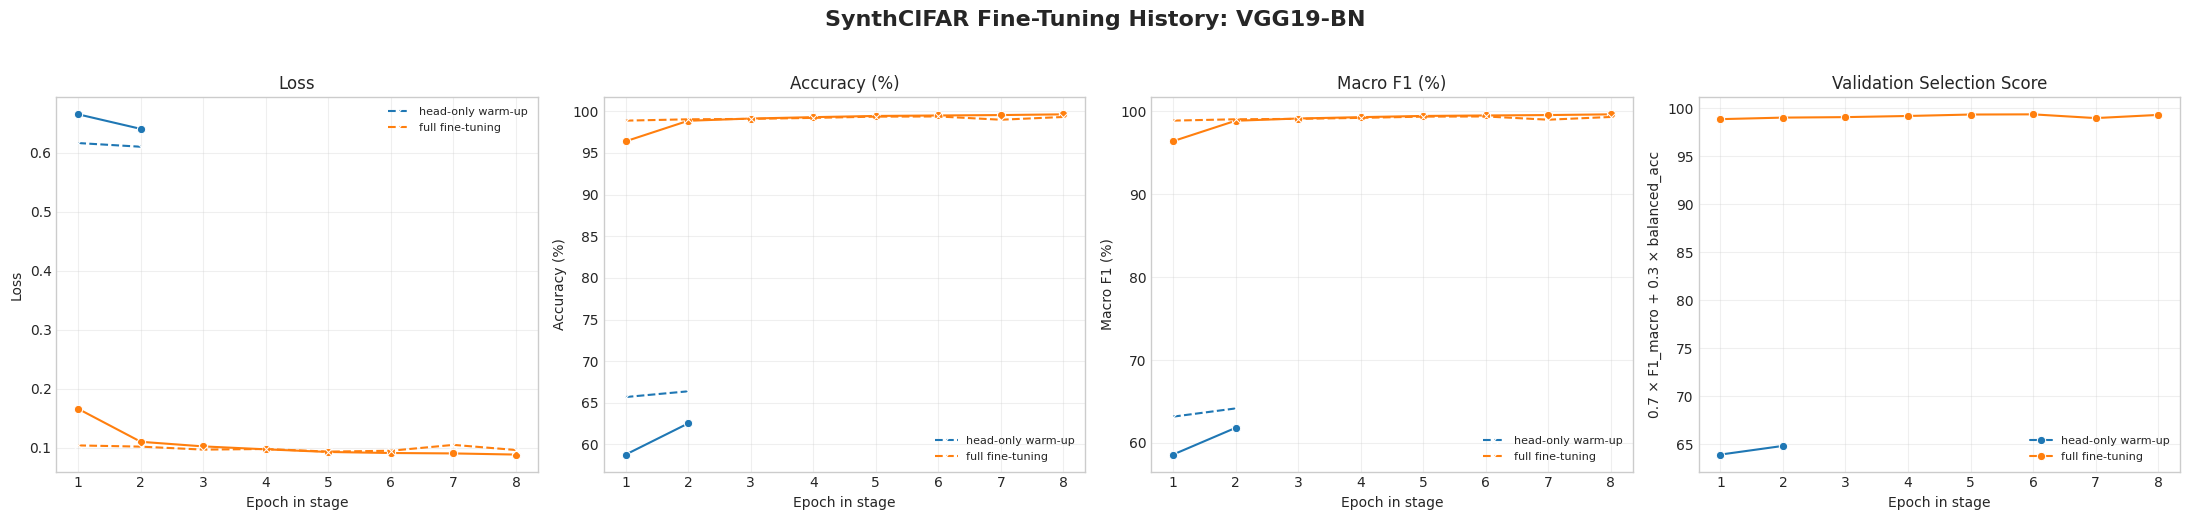

Saved: synth_binary_finetuning_history_VGG19-BN.png


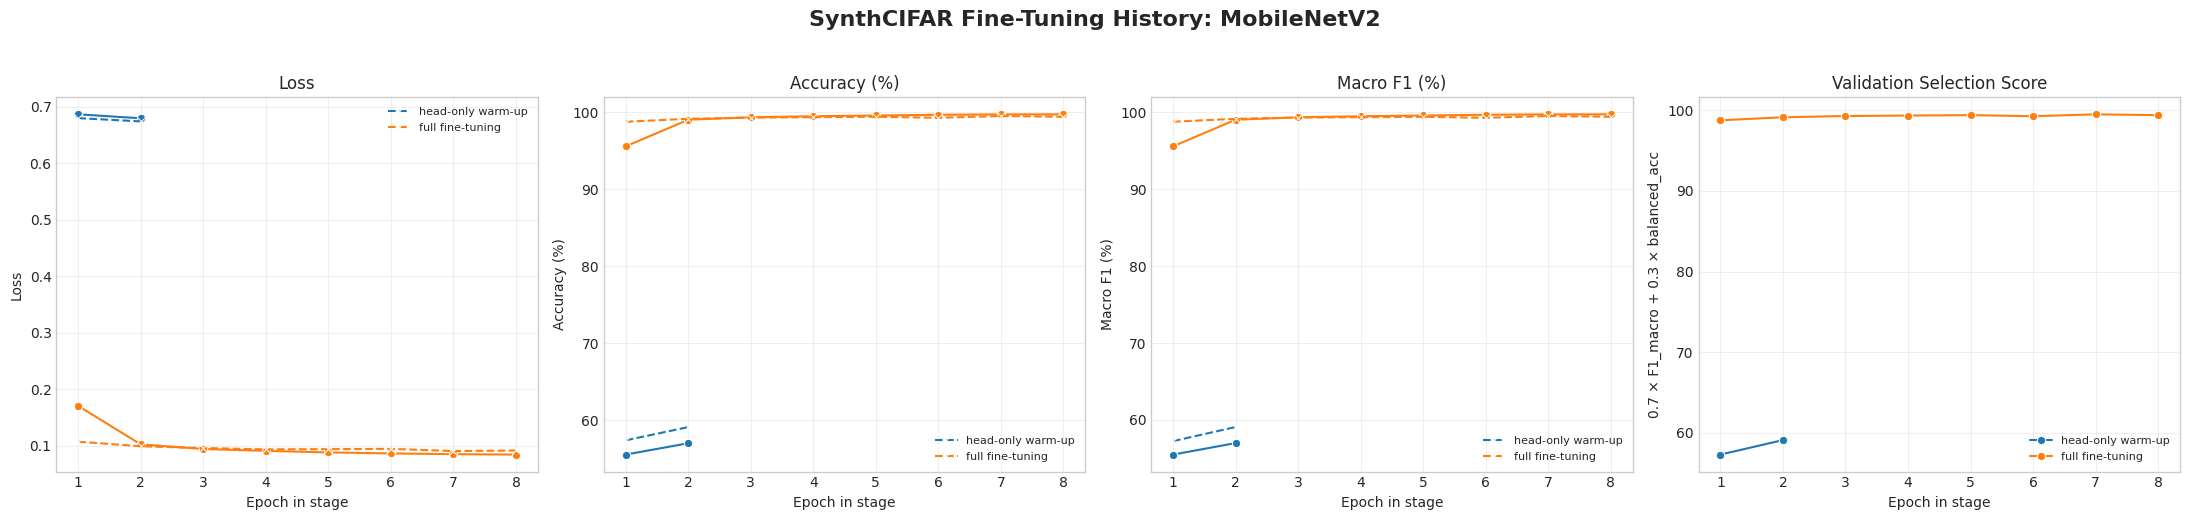

Saved: synth_binary_finetuning_history_MobileNetV2.png


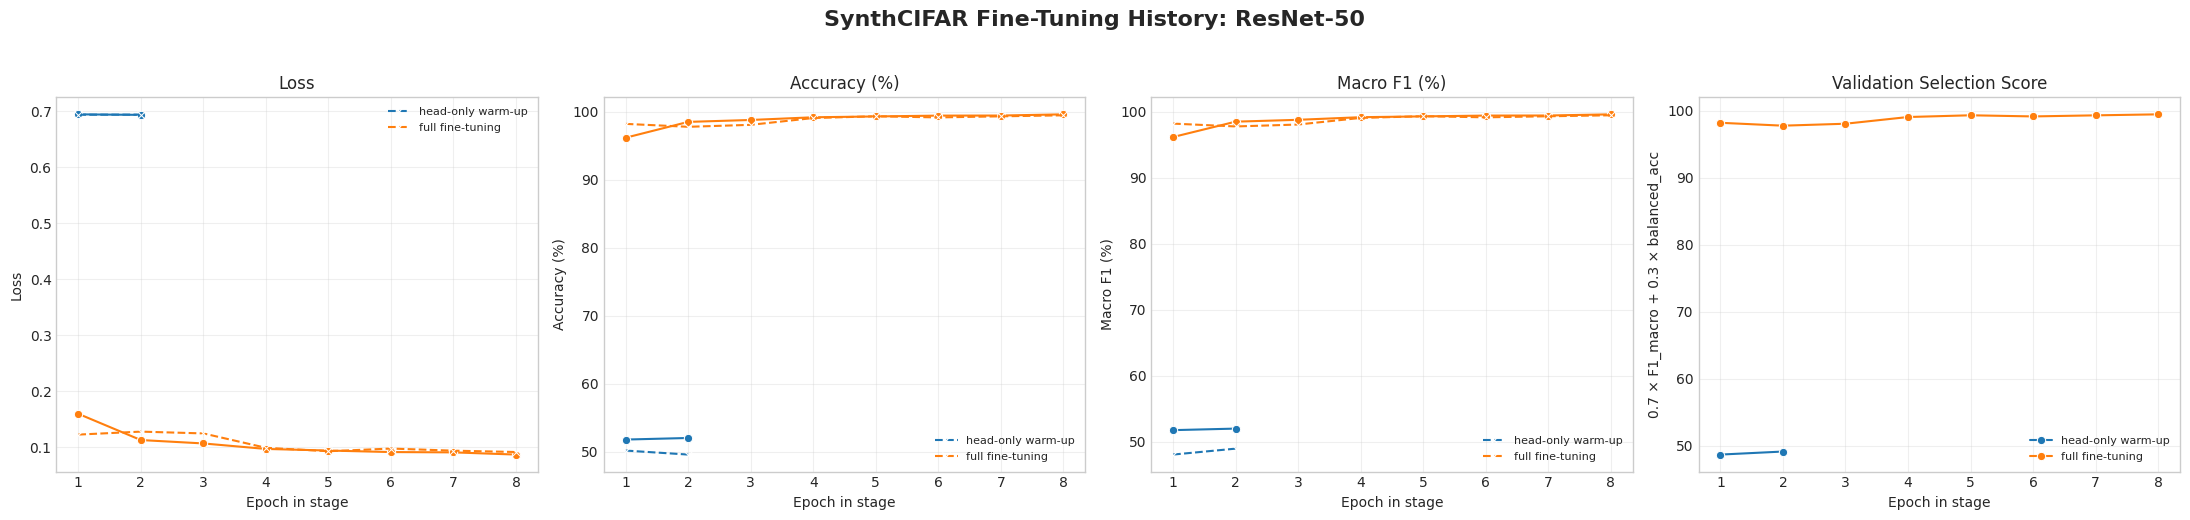

Saved: synth_binary_finetuning_history_ResNet-50.png


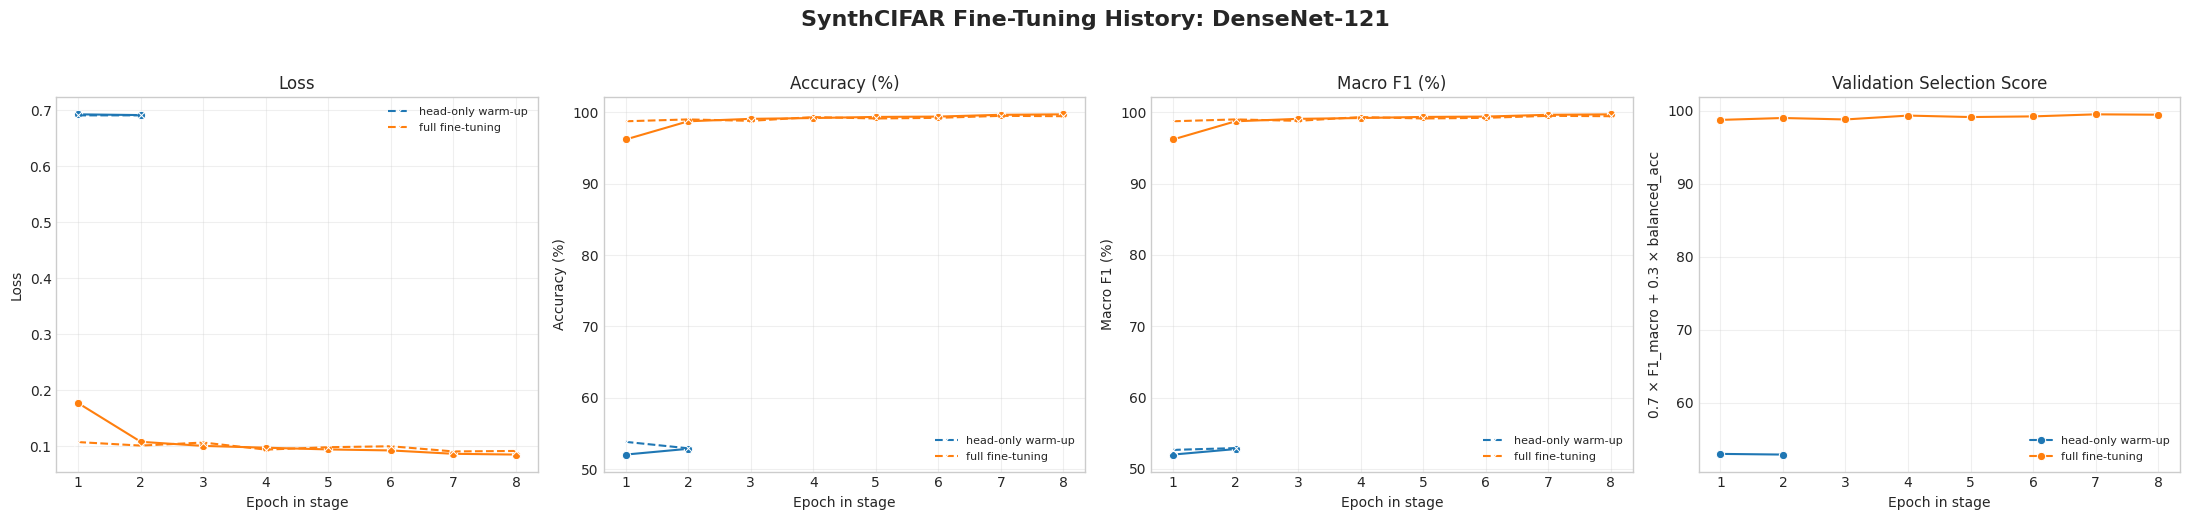

Saved: synth_binary_finetuning_history_DenseNet-121.png


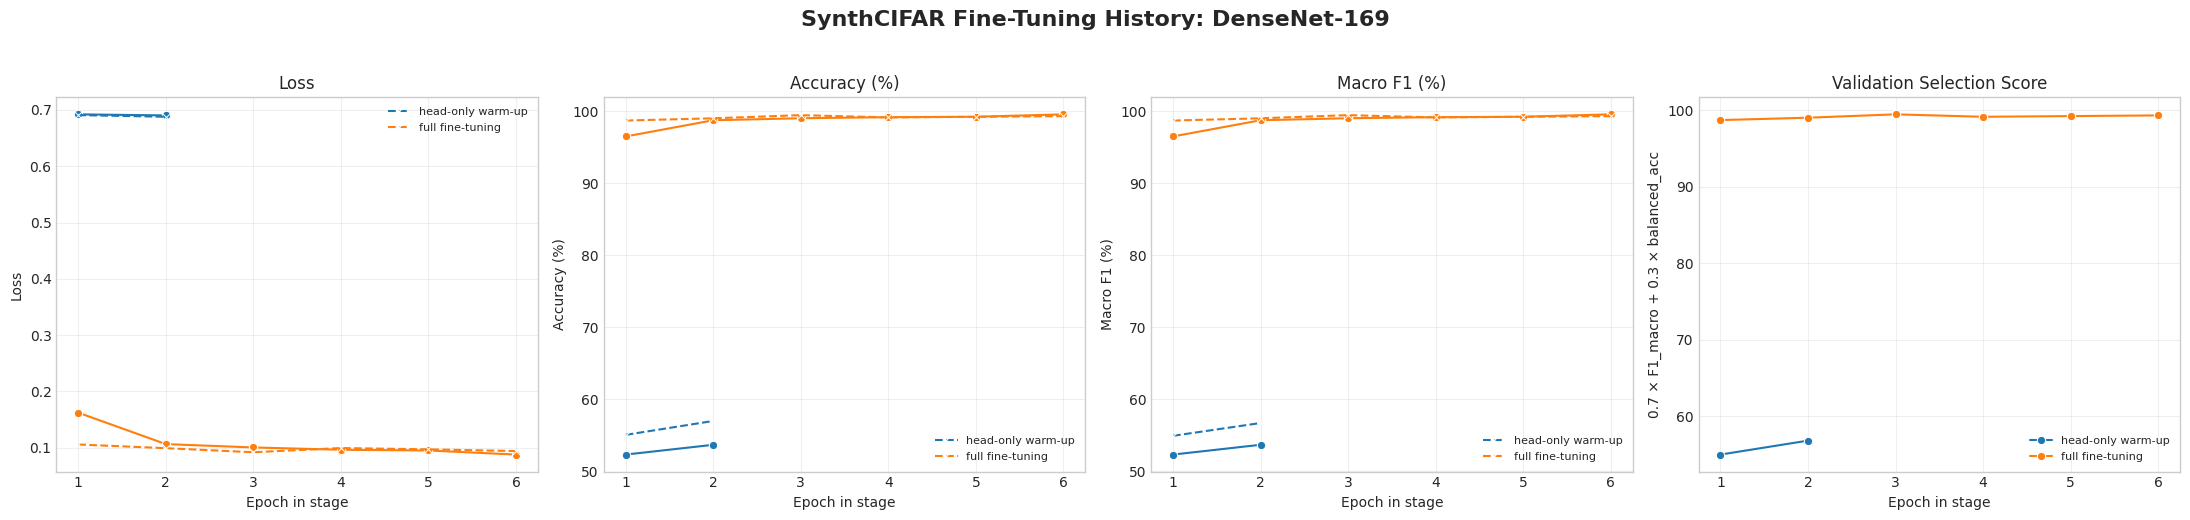

Saved: synth_binary_finetuning_history_DenseNet-169.png


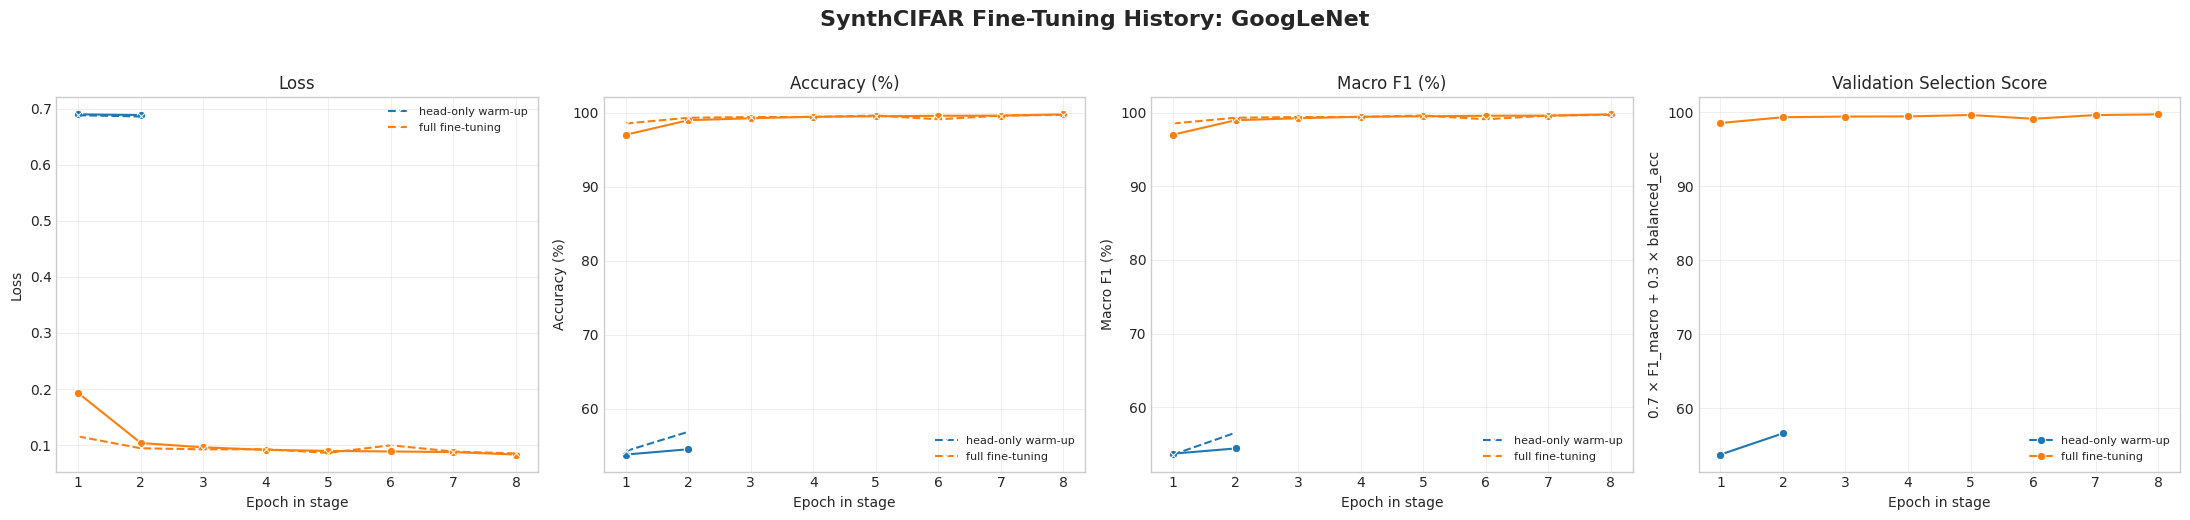

Saved: synth_binary_finetuning_history_GoogLeNet.png


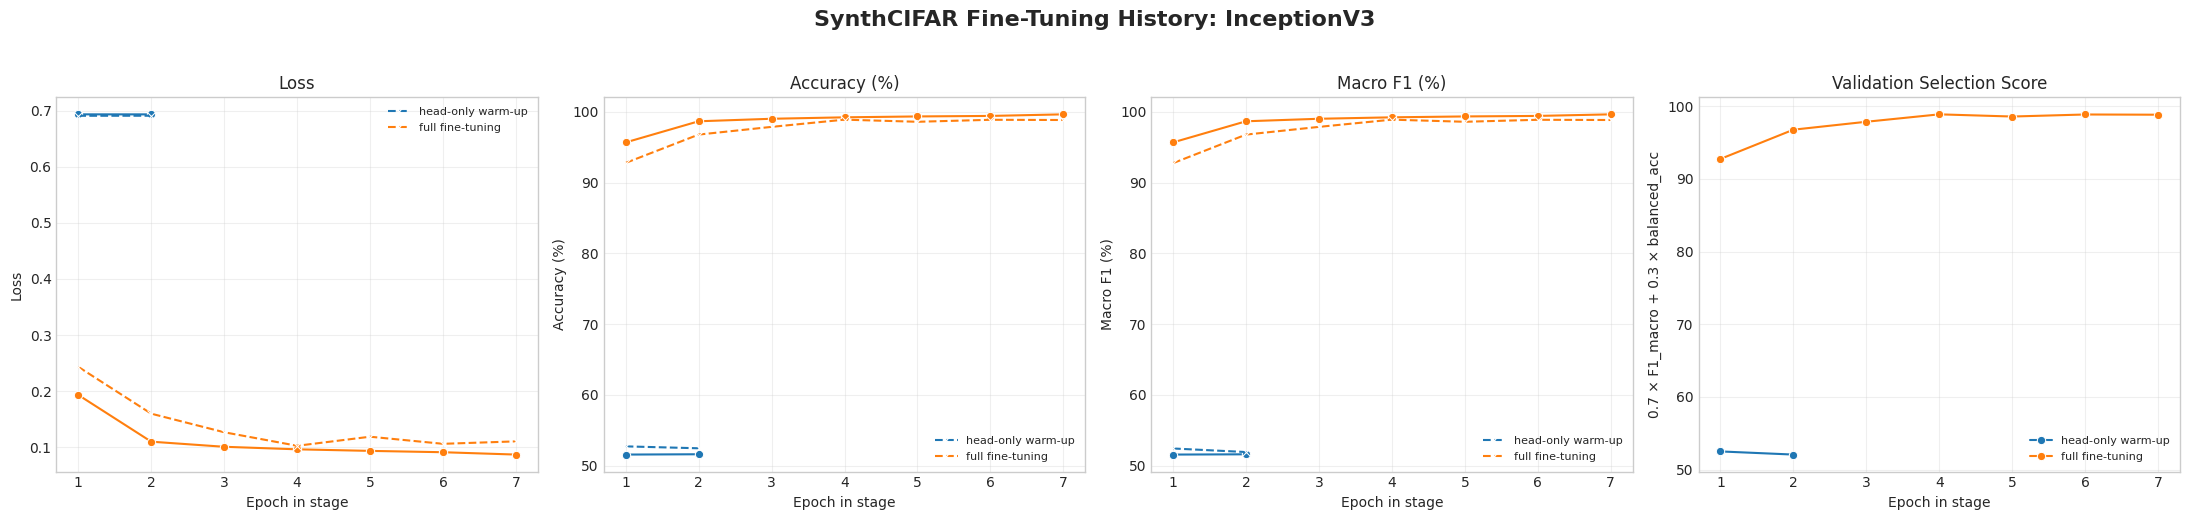

Saved: synth_binary_finetuning_history_InceptionV3.png


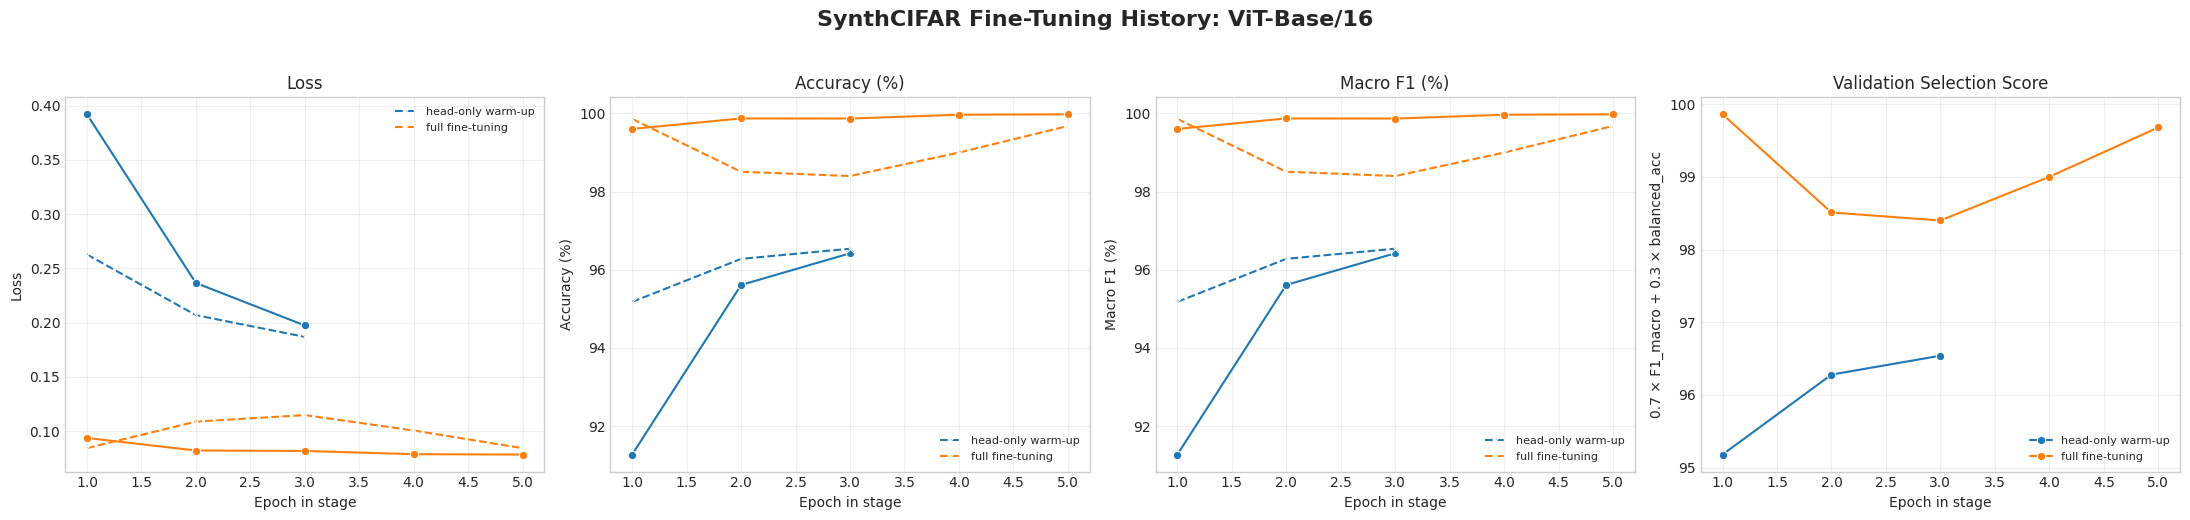

Saved: synth_binary_finetuning_history_ViT-Base-16.png


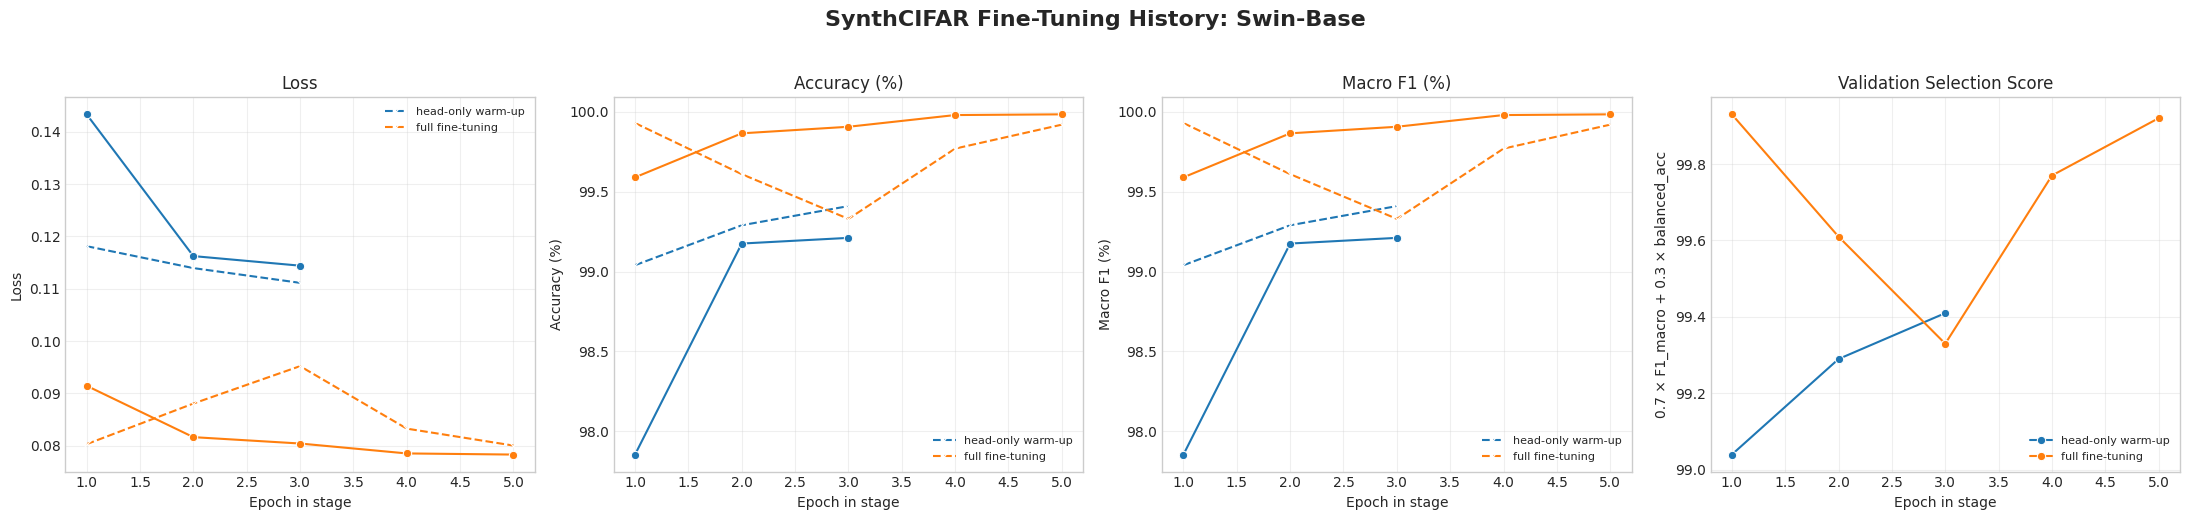

Saved: synth_binary_finetuning_history_Swin-Base.png


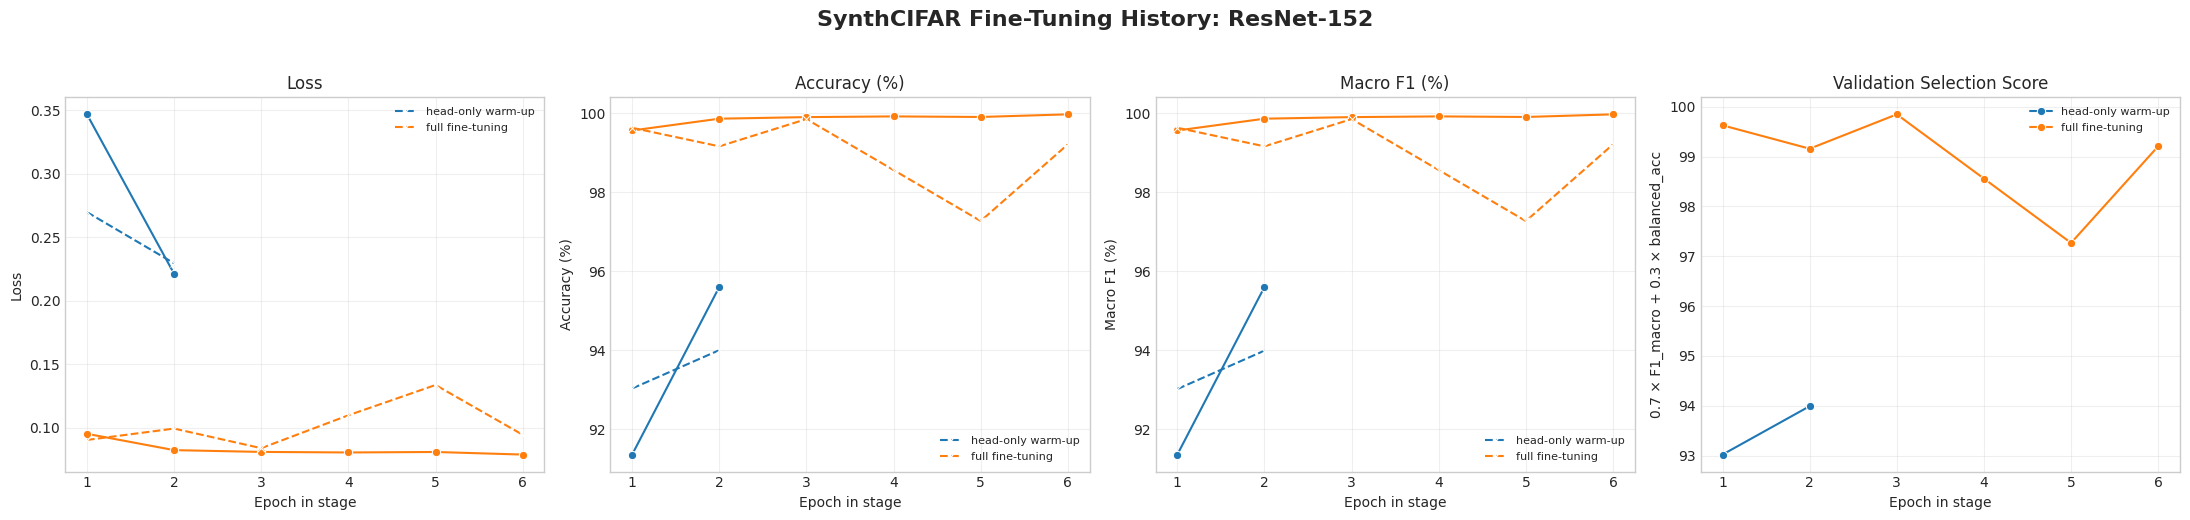

Saved: synth_binary_finetuning_history_ResNet-152.png


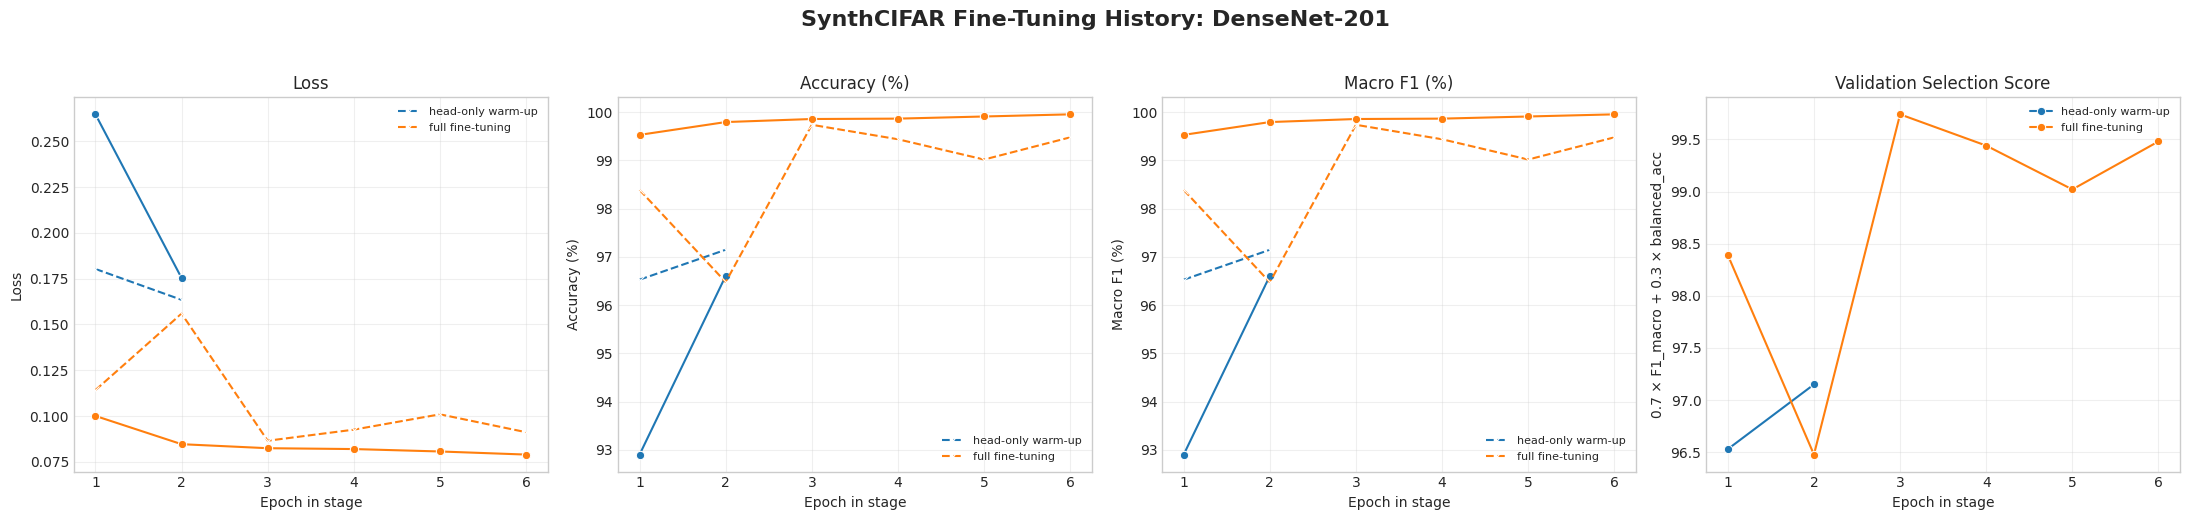

Saved: synth_binary_finetuning_history_DenseNet-201.png


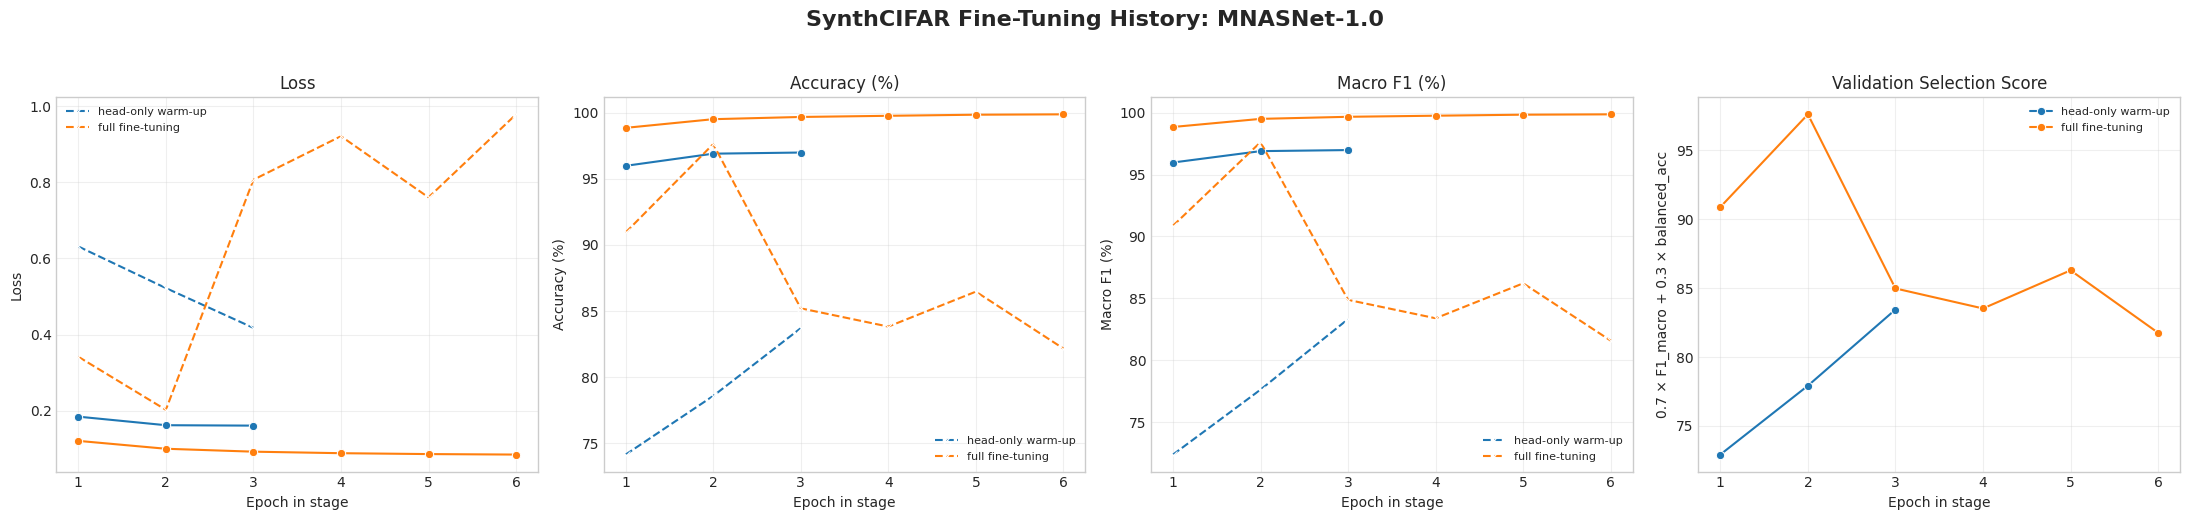

Saved: synth_binary_finetuning_history_MNASNet-1.0.png


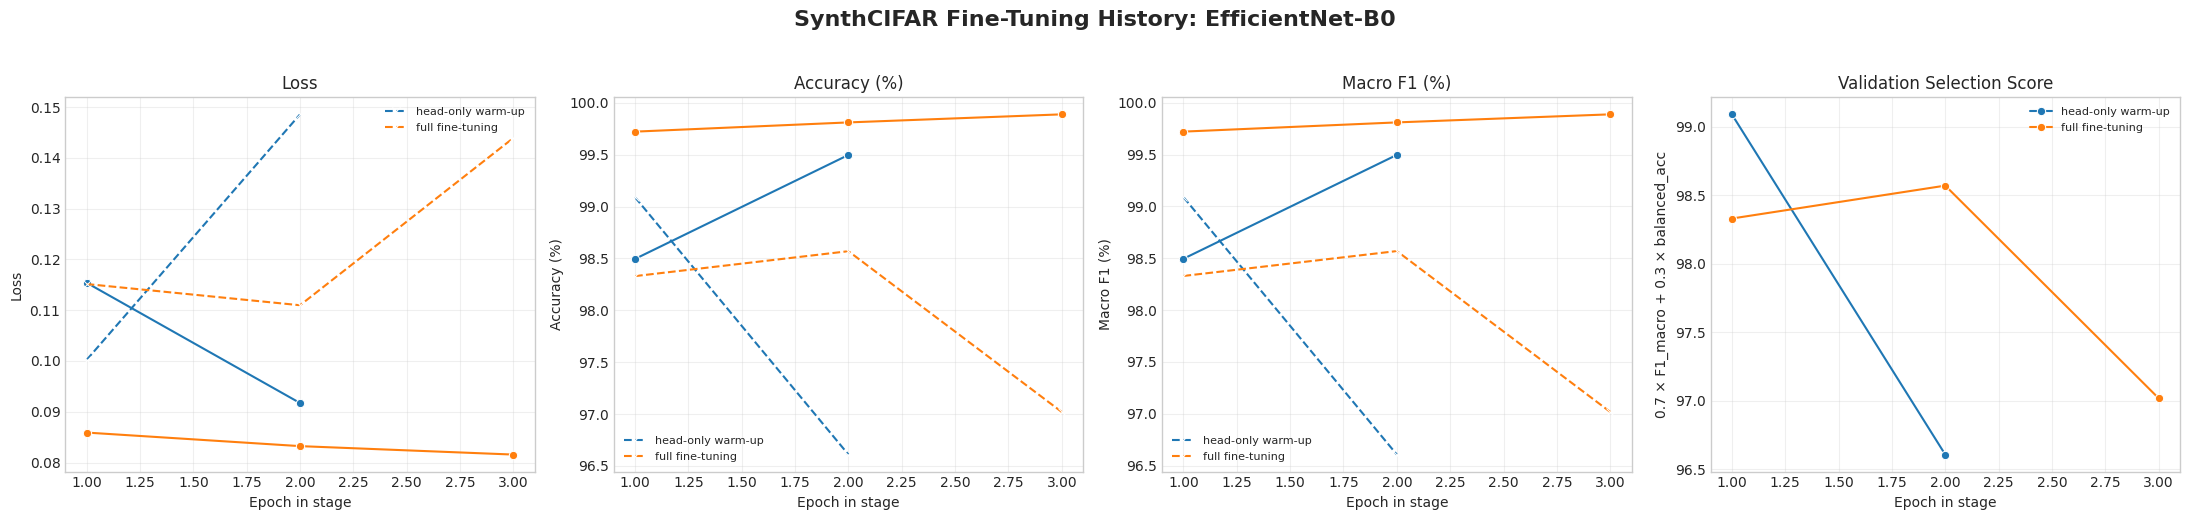

Saved: synth_binary_finetuning_history_EfficientNet-B0.png


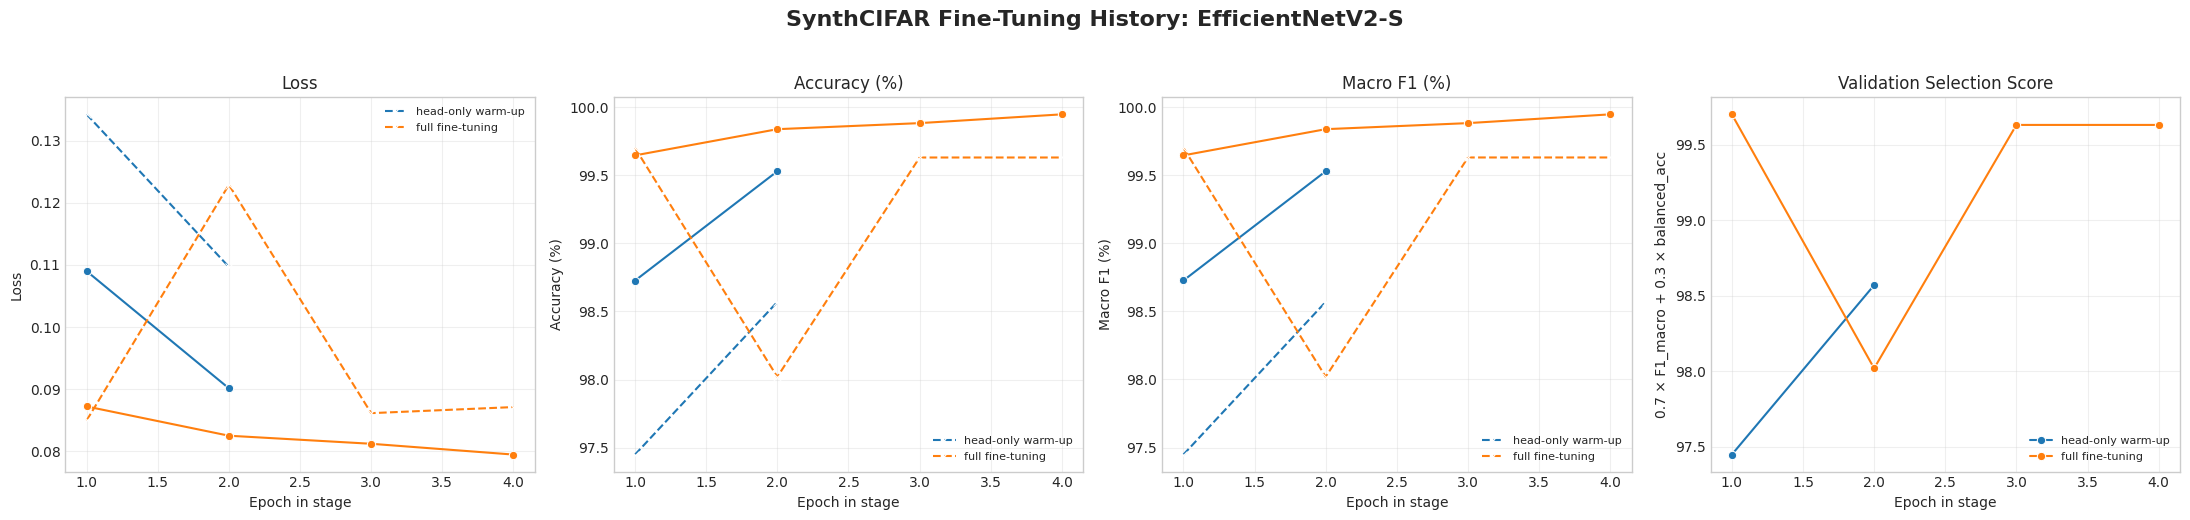

Saved: synth_binary_finetuning_history_EfficientNetV2-S.png


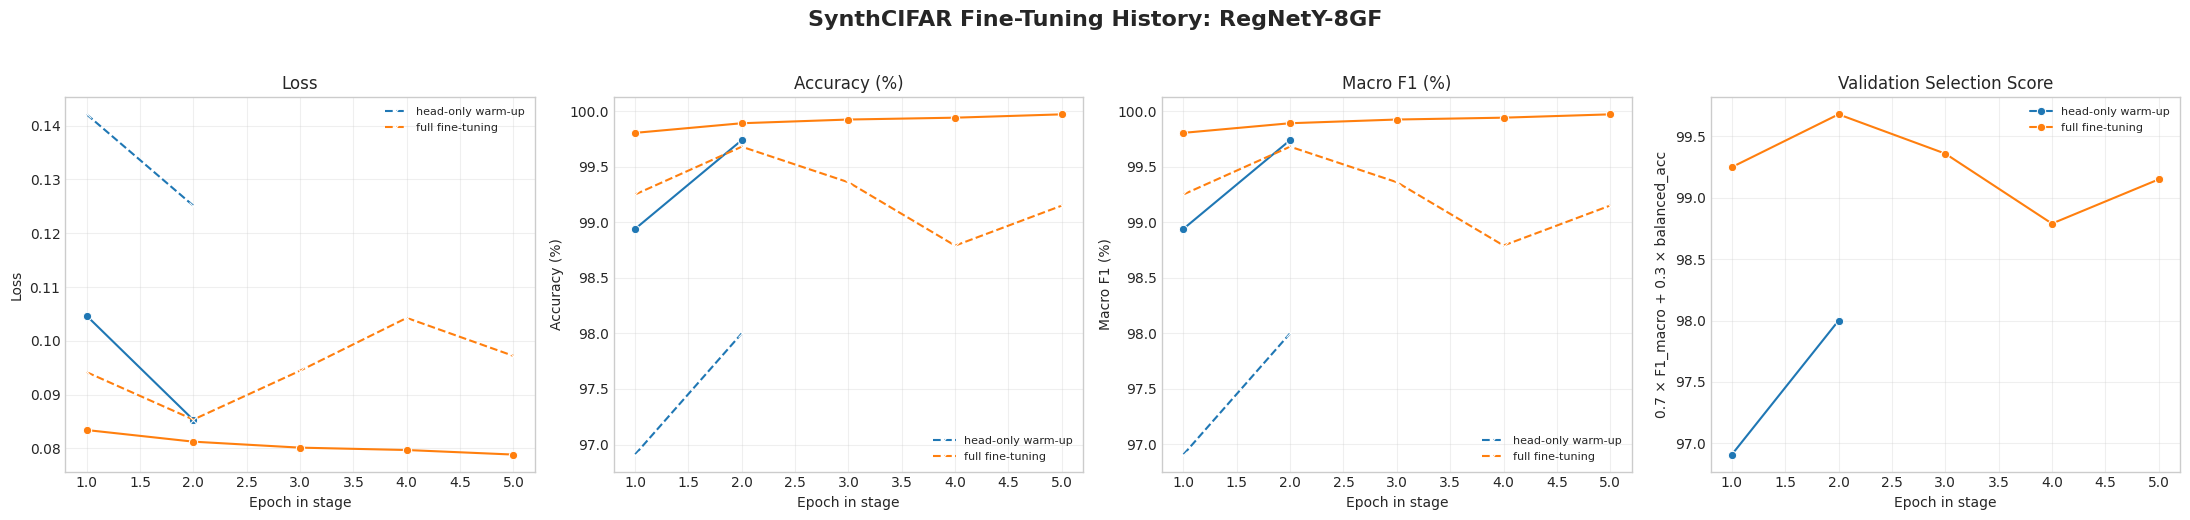

Saved: synth_binary_finetuning_history_RegNetY-8GF.png


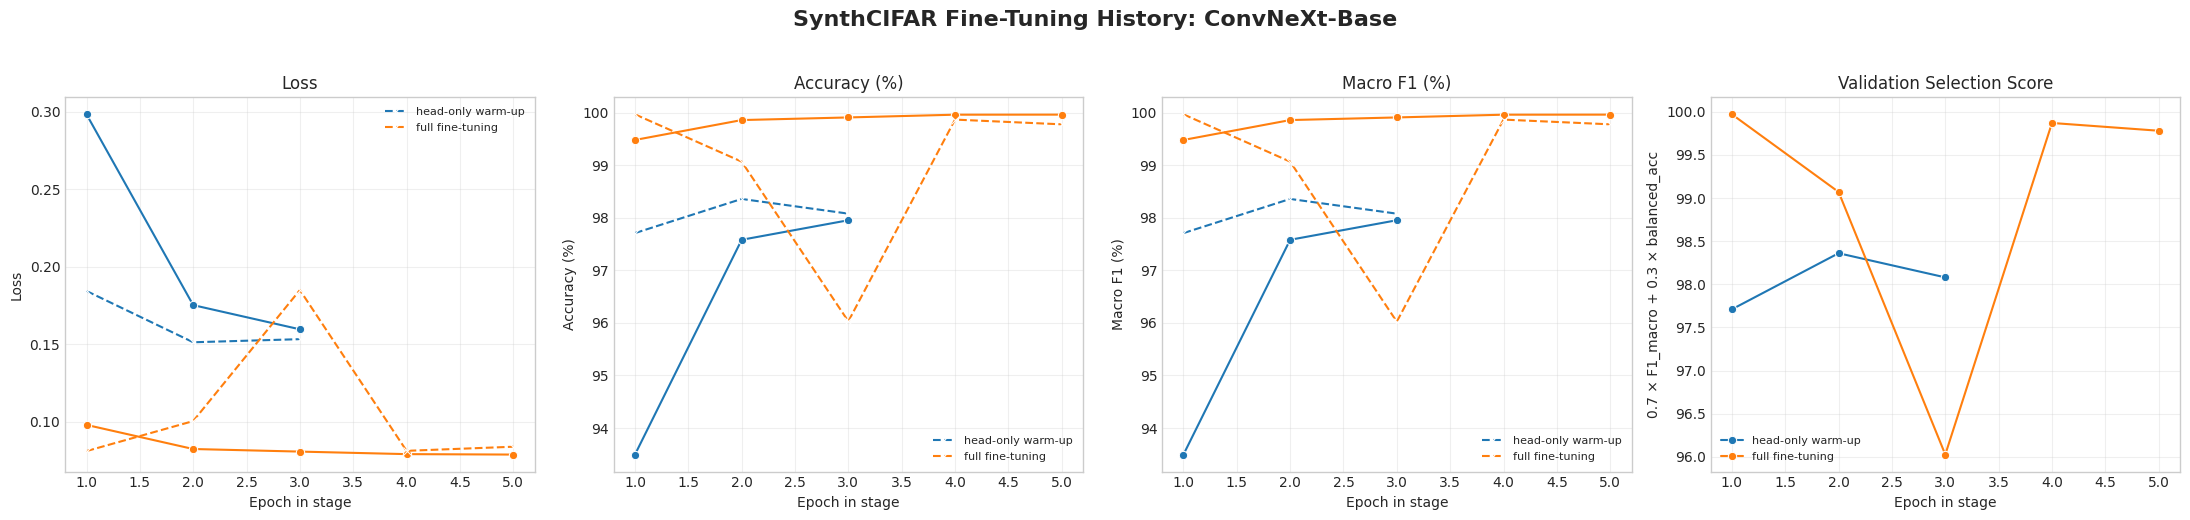

Saved: synth_binary_finetuning_history_ConvNeXt-Base.png


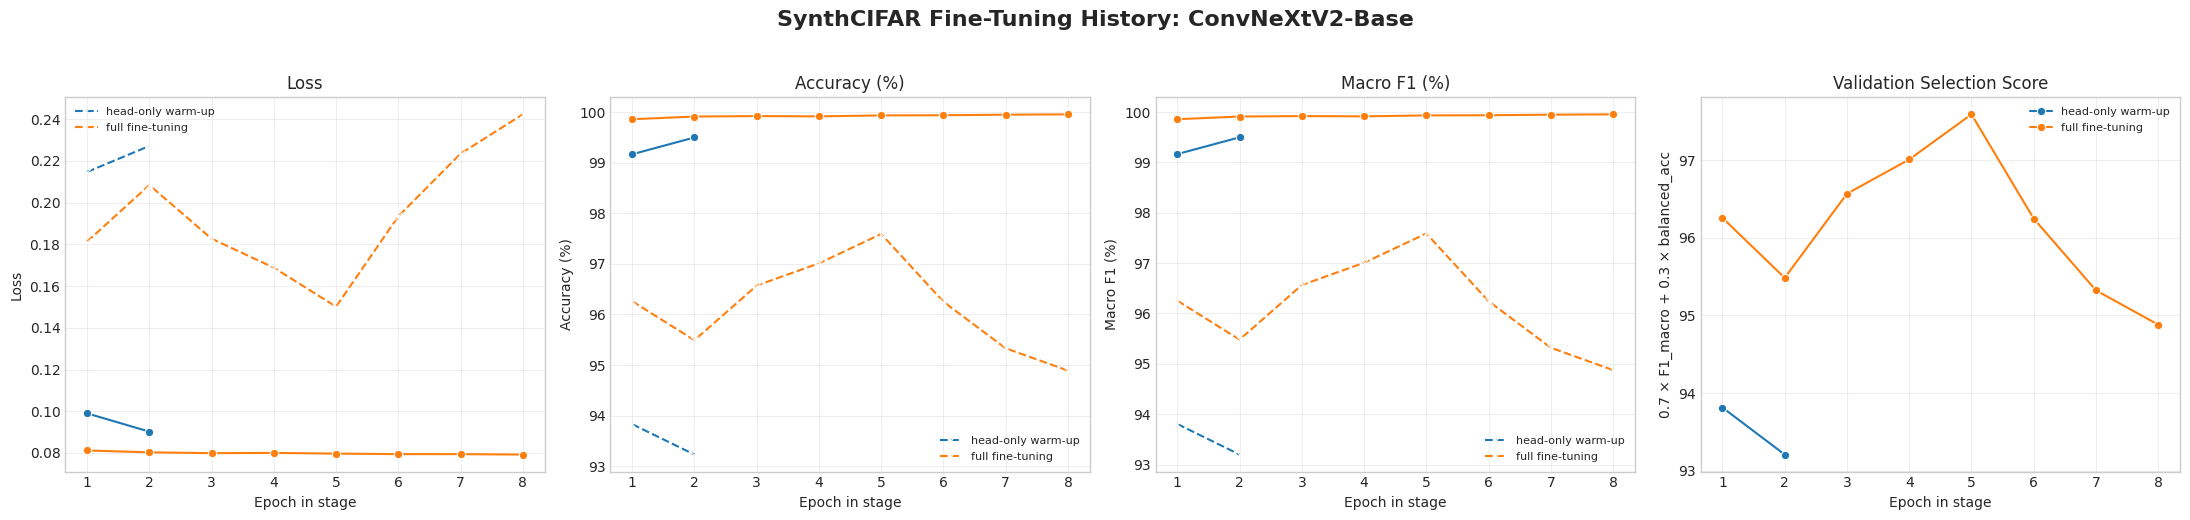

Saved: synth_binary_finetuning_history_ConvNeXtV2-Base.png


In [21]:
for model_name in SYNTH_MODEL_REGISTRY:
    cache_path = CACHE_DIR / f"{model_name.replace('/', '-').replace(' ', '_')}_synth_binary_ft_v1.pth"
    if not cache_path.exists():
        print(f"⚠ History for {model_name} not found at {cache_path}. Skipping.")
        continue

    ckpt = torch.load(cache_path, map_location="cpu")
    history = pd.DataFrame(ckpt["history"])
    if history.empty:
        print(f"⚠ Empty history for {model_name}.")
        continue

    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    fig.suptitle(f"SynthCIFAR Fine-Tuning History: {model_name}", fontsize=16, fontweight="bold", y=1.03)

    sns.lineplot(data=history, x="epoch_in_stage", y="train_loss", hue="stage", marker="o", ax=axes[0])
    sns.lineplot(data=history, x="epoch_in_stage", y="val_loss", hue="stage", marker="x", linestyle="--", ax=axes[0])
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch in stage")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, alpha=0.3)

    sns.lineplot(data=history, x="epoch_in_stage", y="train_acc", hue="stage", marker="o", ax=axes[1])
    sns.lineplot(data=history, x="epoch_in_stage", y="val_acc", hue="stage", marker="x", linestyle="--", ax=axes[1])
    axes[1].set_title("Accuracy (%)")
    axes[1].set_xlabel("Epoch in stage")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].grid(True, alpha=0.3)

    sns.lineplot(data=history, x="epoch_in_stage", y="train_f1_macro", hue="stage", marker="o", ax=axes[2])
    sns.lineplot(data=history, x="epoch_in_stage", y="val_f1_macro", hue="stage", marker="x", linestyle="--", ax=axes[2])
    axes[2].set_title("Macro F1 (%)")
    axes[2].set_xlabel("Epoch in stage")
    axes[2].set_ylabel("Macro F1 (%)")
    axes[2].grid(True, alpha=0.3)

    sns.lineplot(data=history, x="epoch_in_stage", y="selection_score", hue="stage", marker="o", ax=axes[3])
    axes[3].set_title("Validation Selection Score")
    axes[3].set_xlabel("Epoch in stage")
    axes[3].set_ylabel("0.7 × F1_macro + 0.3 × balanced_acc")
    axes[3].grid(True, alpha=0.3)

    for ax in axes:
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            unique = dict(zip(labels, handles))
            ax.legend(unique.values(), unique.keys(), title="", fontsize=8)

    plt.tight_layout()
    fname = f"synth_binary_finetuning_history_{model_name.replace('/', '-').replace(' ', '_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")


## 📊 6 · Scientific Evaluation on SynthCIFAR Test Set

The final evaluation is performed on **`SynthCIFAR/test`** after binary fine-tuning.

### Metric conventions

- **threshold-based metrics:** use the model's default argmax decision
- **threshold-free metrics:** ROC AUC and PR AUC use predicted probabilities

### Reported metrics

Primary metrics:
- Accuracy
- Balanced Accuracy
- Precision
- Recall / Sensitivity
- Specificity
- F1
- ROC AUC
- PR AUC
- MCC
- Cohen's Kappa

Secondary diagnostics:
- Macro F1
- Weighted F1
- NPV
- FPR / FNR
- Log Loss
- Brier Score


In [22]:
SYNTH_RESULTS = {}

print("Running scientific SynthCIFAR evaluation on all binary fine-tuned models …\n")
for name, info in SYNTH_MODEL_REGISTRY.items():
    loader = synth_loaders[info["loader"]]["test"]
    model = info["model"]

    res = evaluate_binary(
        model,
        loader,
        model_name=name,
        class_names=SYNTH_CLASSES,
        positive_index=POSITIVE_CLASS_INDEX,
        desc=f"Evaluating {name}",
    )
    SYNTH_RESULTS[name] = res
    SYNTH_RESULTS[name].update({
        "source": info["source"],
        "params_M": info.get("params_M", float("nan")),
        "macs_G": info.get("macs_G", float("nan")),
    })

    print(
        f"  {name:20s} | "
        f"Acc={res['accuracy']:.2f}% | "
        f"F1(synth)={res['f1_positive']:.2f}% | "
        f"Recall(synth)={res['recall_positive']:.2f}% | "
        f"Spec={res['specificity']:.2f}% | "
        f"ROC-AUC={res['roc_auc']:.2f}% | "
        f"MCC={res['mcc']:.4f}"
    )

print("\n✅ Scientific SynthCIFAR evaluation complete.")


Running scientific SynthCIFAR evaluation on all binary fine-tuned models …



Evaluating VGG19-BN:   0%|          | 0/157 [00:00<?, ?it/s]

  VGG19-BN             | Acc=99.52% | F1(synth)=99.52% | Recall(synth)=99.56% | Spec=99.48% | ROC-AUC=99.97% | MCC=0.9904


Evaluating MobileNetV2:   0%|          | 0/157 [00:00<?, ?it/s]

  MobileNetV2          | Acc=99.61% | F1(synth)=99.61% | Recall(synth)=99.55% | Spec=99.67% | ROC-AUC=99.97% | MCC=0.9922


...

  RegNetY-8GF          | Acc=99.59% | F1(synth)=99.59% | Recall(synth)=99.21% | Spec=99.98% | ROC-AUC=100.00% | MCC=0.9919


Evaluating ConvNeXt-Base:   0%|          | 0/157 [00:00<?, ?it/s]

  ConvNeXt-Base        | Acc=99.91% | F1(synth)=99.91% | Recall(synth)=99.87% | Spec=99.95% | ROC-AUC=99.99% | MCC=0.9982


Evaluating ConvNeXtV2-Base:   0%|          | 0/157 [00:00<?, ?it/s]

  ConvNeXtV2-Base      | Acc=97.34% | F1(synth)=97.27% | Recall(synth)=94.70% | Spec=99.99% | ROC-AUC=100.00% | MCC=0.9482

✅ Scientific SynthCIFAR evaluation complete.


## 📋 7 · Comparison Table and Ranking

The ranking below is based on a balanced set of classification-quality metrics suitable for a scientific article:

- Accuracy
- Balanced Accuracy
- F1
- ROC AUC
- PR AUC
- MCC

No speed or efficiency metrics are used in the ranking.


In [23]:
rows = []
for name, r in SYNTH_RESULTS.items():
    rows.append({
        "Model": name,
        "Accuracy (%)": round(r["accuracy"], 2),
        "Balanced Accuracy (%)": round(r["balanced_accuracy"], 2),
        "Precision (%)": round(r["precision_positive"], 2),
        "Recall (%)": round(r["recall_positive"], 2),
        "Specificity (%)": round(r["specificity"], 2),
        "F1 (%)": round(r["f1_positive"], 2),
        "Precision Macro (%)": round(r["precision_macro"], 2),
        "Recall Macro (%)": round(r["recall_macro"], 2),
        "F1 Macro (%)": round(r["f1_macro"], 2),
        "F1 Weighted (%)": round(r["f1_weighted"], 2),
        "NPV (%)": round(r["npv"], 2),
        "FPR (%)": round(r["fpr"], 2),
        "FNR (%)": round(r["fnr"], 2),
        "ROC AUC (%)": round(r["roc_auc"], 2),
        "PR AUC (%)": round(r["pr_auc"], 2),
        "MCC": round(r["mcc"], 4),
        "Cohen's Kappa": round(r["cohen_kappa"], 4),
        "Log Loss": round(r["log_loss"], 4),
        "Brier Score": round(r["brier_score"], 4),
        "Source": r["source"],
    })

df = pd.DataFrame(rows)

rank_high_cols = [
    "Accuracy (%)",
    "Balanced Accuracy (%)",
    "F1 (%)",
    "ROC AUC (%)",
    "PR AUC (%)",
    "MCC",
]
rank_low_cols = ["Log Loss", "Brier Score", "FPR (%)", "FNR (%)"]

for col in rank_high_cols:
    df[f"Rank {col}"] = df[col].rank(ascending=False, method="min")
for col in rank_low_cols:
    df[f"Rank {col}"] = df[col].rank(ascending=True, method="min")

rank_cols = [c for c in df.columns if c.startswith("Rank ")]
df["Mean Rank"] = df[rank_cols].mean(axis=1)

df = df.sort_values(
    ["Mean Rank", "F1 (%)", "ROC AUC (%)", "Accuracy (%)"],
    ascending=[True, False, False, False]
).reset_index(drop=True)

df.index += 1
df.insert(0, "Overall Rank", df.index)

display(
    df.style
      .background_gradient(
          subset=[
              "Accuracy (%)", "Balanced Accuracy (%)", "Precision (%)",
              "Recall (%)", "Specificity (%)", "F1 (%)",
              "Precision Macro (%)", "Recall Macro (%)", "F1 Macro (%)",
              "F1 Weighted (%)", "NPV (%)", "ROC AUC (%)", "PR AUC (%)"
          ],
          cmap="RdYlGn",
      )
      .background_gradient(subset=["MCC", "Cohen's Kappa"], cmap="RdYlGn")
      .background_gradient(subset=["FPR (%)", "FNR (%)", "Log Loss", "Brier Score", "Mean Rank"], cmap="RdYlGn_r")
      .format({
          "Accuracy (%)": "{:.2f}",
          "Balanced Accuracy (%)": "{:.2f}",
          "Precision (%)": "{:.2f}",
          "Recall (%)": "{:.2f}",
          "Specificity (%)": "{:.2f}",
          "F1 (%)": "{:.2f}",
          "Precision Macro (%)": "{:.2f}",
          "Recall Macro (%)": "{:.2f}",
          "F1 Macro (%)": "{:.2f}",
          "F1 Weighted (%)": "{:.2f}",
          "NPV (%)": "{:.2f}",
          "FPR (%)": "{:.2f}",
          "FNR (%)": "{:.2f}",
          "ROC AUC (%)": "{:.2f}",
          "PR AUC (%)": "{:.2f}",
          "MCC": "{:.4f}",
          "Cohen's Kappa": "{:.4f}",
          "Log Loss": "{:.4f}",
          "Brier Score": "{:.4f}",
          "Mean Rank": "{:.2f}",
      })
      .set_caption("SynthCIFAR binary benchmark (positive class = synthetic)")
)

df.to_csv("synthcifar_binary_scientific_report_metrics.csv", index=False)
print("Saved: synthcifar_binary_scientific_report_metrics.csv")


,Overall Rank,Model,Accuracy (%),Balanced Accuracy (%),Precision (%),Recall (%),Specificity (%),F1 (%),Precision Macro (%),Recall Macro (%),F1 Macro (%),F1 Weighted (%),NPV (%),FPR (%),FNR (%),ROC AUC (%),PR AUC (%),MCC,Cohen's Kappa,Log Loss,Brier Score,Source,Rank Accuracy (%),Rank Balanced Accuracy (%),Rank F1 (%),Rank ROC AUC (%),Rank PR AUC (%),Rank MCC,Rank Log Loss,Rank Brier Score,Rank FPR (%),Rank FNR (%),Mean Rank
1,1,Swin-Base,99.94,99.94,99.96,99.93,99.96,99.94,99.95,99.94,99.94,99.94,99.93,0.04,0.07,100.00,100.00,0.9989,0.9989,0.0147,0.0007,HuggingFace Hub (explicit CIFAR-10 checkpoint),1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,1.000000,1.40
2,2,ViT-Base/16,99.88,99.88,99.88,99.88,99.88,99.88,99.88,99.88,99.88,99.88,99.88,0.12,0.12,100.00,100.00,0.9976,0.9976,0.0203,0.0013,HuggingFace Hub (explicit CIFAR-10 checkpoint),3.000000,3.000000,3.000000,1.000000,1.000000,3.000000,4.000000,3.000000,9.000000,2.000000,3.20
3,3,ConvNeXt-Base,99.91,99.91,99.95,99.87,99.95,99.91,99.91,99.91,99.91,99.91,99.87,0.05,0.13,99.99,99.99,0.9982,0.9982,0.0171,0.0010,transfer-learned on CIFAR-10 with safer family-aware protocol [convnext],2.000000,2.000000,2.000000,7.000000,8.000000,2.000000,2.000000,2.000000,8.000000,3.000000,3.80
4,4,ResNet-152,99.77,99.77,99.96,99.58,99.96,99.77,99.77,99.77,99.77,99.77,99.58,0.04,0.42,100.00,100.00,0.9954,0.9954,0.0231,0.0022,transfer-learned on CIFAR-10 with safer family-aware protocol [resnet],5.000000,5.000000,5.000000,1.000000,1.000000,5.000000,8.000000,5.000000,5.000000,7.000000,4.70
5,5,DenseNet-201,99.69,99.69,99.96,99.43,99.96,99.69,99.70,99.69,99.69,99.69,99.43,0.04,0.57,100.00,100.00,0.9939,0.9939,0.0179,0.0025,transfer-learned on CIFAR-10 with safer family-aware protocol [densenet],7.000000,7.000000,7.000000,1.000000,1.000000,7.000000,3.000000,6.000000,5.000000,10.000000,5.40
6,6,EfficientNetV2-S,99.72,99.72,100.00,99.43,100.00,99.71,99.72,99.72,99.71,99.71,99.43,0.00,0.57,99.99,100.00,0.9943,0.9943,0.0225,0.0025,transfer-learned on CIFAR-10 with safer family-aware protocol [efficientnetv2],6.000000,6.000000,6.000000,7.000000,1.000000,6.000000,6.000000,6.000000,1.000000,10.000000,5.50
7,7,GoogLeNet,99.78,99.78,99.69,99.86,99.69,99.78,99.78,99.78,99.77,99.77,99.86,0.31,0.14,99.99,99.98,0.9955,0.9955,0.0209,0.0021,huyvnphan/PyTorch_CIFAR10 (official repo + gdown weights),4.000000,4.000000,4.000000,7.000000,10.000000,4.000000,5.000000,4.000000,12.000000,4.000000,5.80
8,8,RegNetY-8GF,99.59,99.59,99.98,99.21,99.98,99.59,99.60,99.59,99.59,99.59,99.22,0.02,0.79,100.00,100.00,0.9919,0.9919,0.0266,0.0033,transfer-learned on CIFAR-10 with safer family-aware protocol [regnet],9.000000,9.000000,9.000000,1.000000,1.000000,9.000000,10.000000,9.000000,3.000000,14.000000,7.40
9,9,MobileNetV2,99.61,99.61,99.67,99.55,99.67,99.61,99.61,99.61,99.61,99.61,99.55,0.33,0.45,99.97,99.95,0.9922,0.9922,0.0227,0.0031,torch.hub / chenyaofo (CIFAR-10 native),8.000000,8.000000,8.000000,12.000000,15.000000,8.000000,7.000000,8.000000,13.000000,9.000000,9.60
10,10,ResNet-50,99.59,99.58,99.53,99.64,99.53,99.59,99.59,99.58,99.58,99.58,99.64,0.47,0.36,99.98,99.98,0.9917,0.9917,0.0261,0.0037,huyvnphan/PyTorch_CIFAR10 (official repo + gdown weights),9.000000,10.000000,9.000000,11.000000,10.000000,10.000000,9.000000,10.000000,14.000000,6.000000,9.80


Saved: synthcifar_binary_scientific_report_metrics.csv


## 📉 8 · Confusion Matrices for All Models

Because this is a binary task, the full set of confusion matrices can be displayed compactly.  
Each panel shows the **row-normalized confusion matrix (%)** for one model.


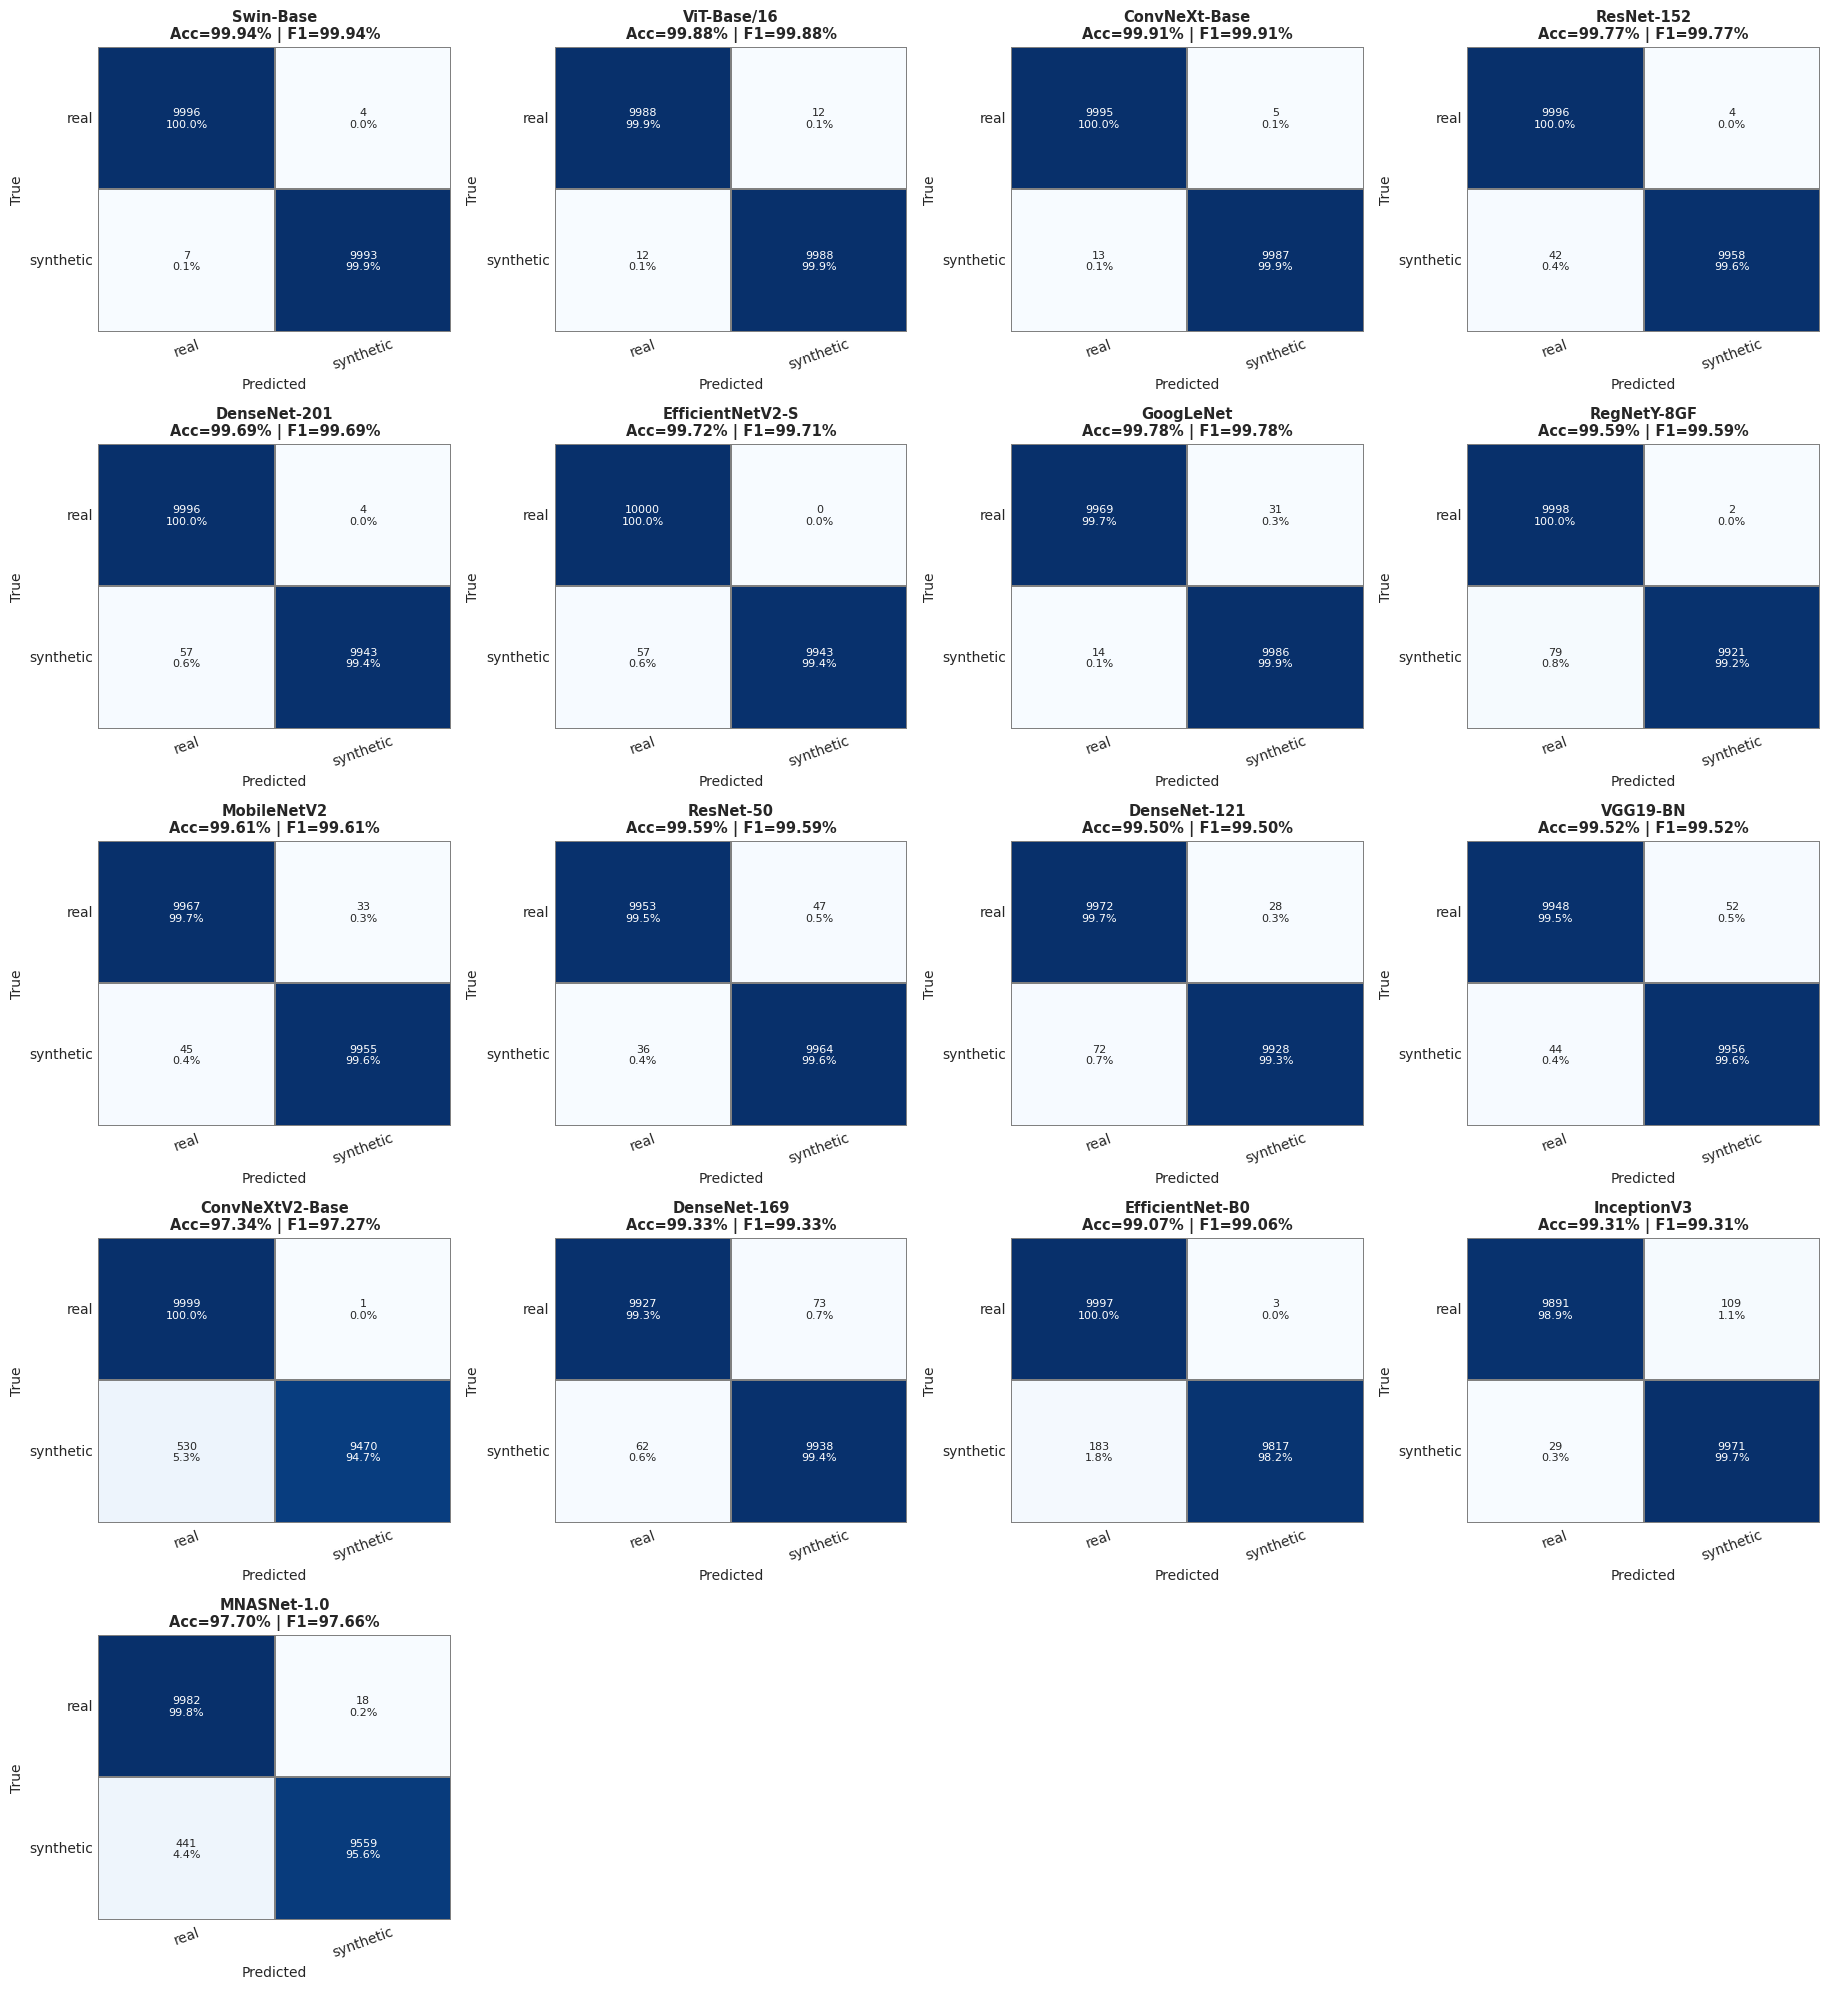

Saved: synthcifar_confusion_matrices_all_models.png


In [34]:
ordered_models = df["Model"].tolist()
n_cols = 4
n_rows = int(np.ceil(len(ordered_models) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.6 * n_cols, 4.0 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, model_name in zip(axes, ordered_models):
    cm = SYNTH_RESULTS[model_name]["confusion_matrix"]
    cm_norm = SYNTH_RESULTS[model_name]["confusion_matrix_norm"]
    acc = SYNTH_RESULTS[model_name]["accuracy"]
    f1s = SYNTH_RESULTS[model_name]["f1_positive"]

    annot = np.empty_like(cm).astype(object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm[i, j]}\n{cm_norm[i, j]:.1f}%"

    sns.heatmap(
        cm_norm,
        annot=annot,
        fmt="",
        cmap="Blues",
        cbar=False,
        linewidths=0.3,
        linecolor="gray",
        xticklabels=SYNTH_CLASSES,
        yticklabels=SYNTH_CLASSES,
        ax=ax,
        vmin=0,
        vmax=100,
        annot_kws={"size": 8},
    )
    ax.set_title(f"{model_name}\nAcc={acc:.2f}% | F1={f1s:.2f}%", fontsize=10.5, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=20)
    ax.tick_params(axis="y", rotation=0)

for ax in axes[len(ordered_models):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("synthcifar_confusion_matrices_all_models.png", dpi=160, bbox_inches="tight")
plt.show()
print("Saved: synthcifar_confusion_matrices_all_models.png")


## 📈 9 · ROC and Precision–Recall Curves

ROC AUC and PR AUC are especially informative for a scientific article because they summarize probability ranking quality across thresholds.

The plots below focus on the **top 8 models by overall rank**.


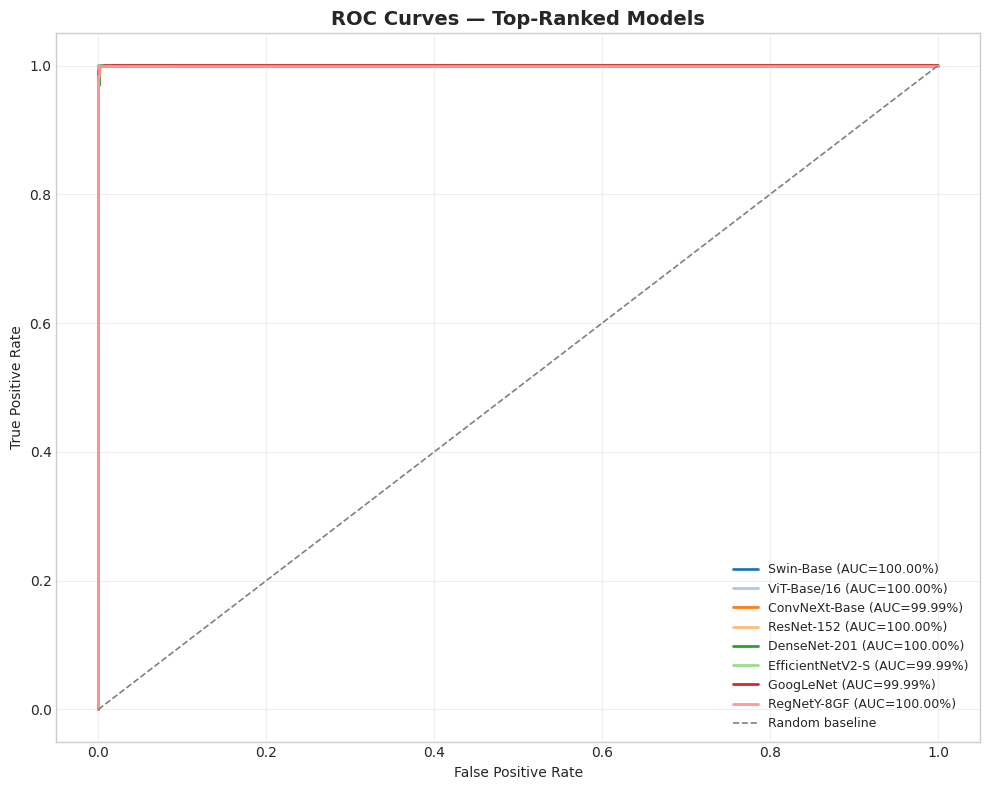

Saved: synthcifar_roc_curves_top_models.png


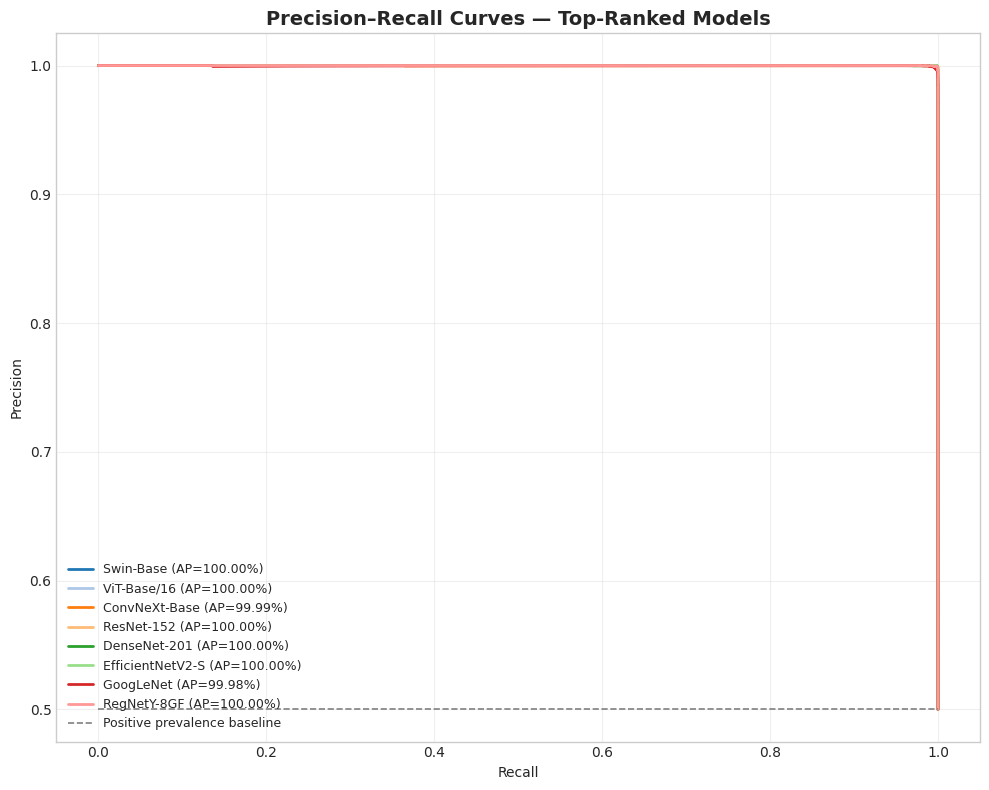

Saved: synthcifar_pr_curves_top_models.png


In [25]:
top_models = df.head(min(8, len(df)))["Model"].tolist()

fig, ax = plt.subplots(figsize=(10, 8))
for i, model_name in enumerate(top_models):
    fpr_curve, tpr_curve = SYNTH_RESULTS[model_name]["roc_curve"]
    auc_score = SYNTH_RESULTS[model_name]["roc_auc"]
    ax.plot(fpr_curve, tpr_curve, linewidth=2, label=f"{model_name} (AUC={auc_score:.2f}%)", color=PALETTE[i])

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1.2, label="Random baseline")
ax.set_title("ROC Curves — Top-Ranked Models", fontsize=14, fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("synthcifar_roc_curves_top_models.png", dpi=160, bbox_inches="tight")
plt.show()
print("Saved: synthcifar_roc_curves_top_models.png")

fig, ax = plt.subplots(figsize=(10, 8))
positive_rate = (test_targets == POSITIVE_CLASS_INDEX).mean()
for i, model_name in enumerate(top_models):
    recall_curve, precision_curve = SYNTH_RESULTS[model_name]["pr_curve"]
    pr_auc = SYNTH_RESULTS[model_name]["pr_auc"]
    ax.plot(recall_curve, precision_curve, linewidth=2, label=f"{model_name} (AP={pr_auc:.2f}%)", color=PALETTE[i])

ax.hlines(positive_rate, 0, 1, linestyle="--", color="gray", linewidth=1.2, label="Positive prevalence baseline")
ax.set_title("Precision–Recall Curves — Top-Ranked Models", fontsize=14, fontweight="bold")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="lower left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("synthcifar_pr_curves_top_models.png", dpi=160, bbox_inches="tight")
plt.show()
print("Saved: synthcifar_pr_curves_top_models.png")


## 🧪 10 · Additional Article-Ready Diagnostics

This section adds diagnostics that are often useful in a paper:

1. grouped comparison across the main metrics
2. calibration curves
3. probability-distribution separation for the best-ranked model
4. per-class metric table for the best-ranked model


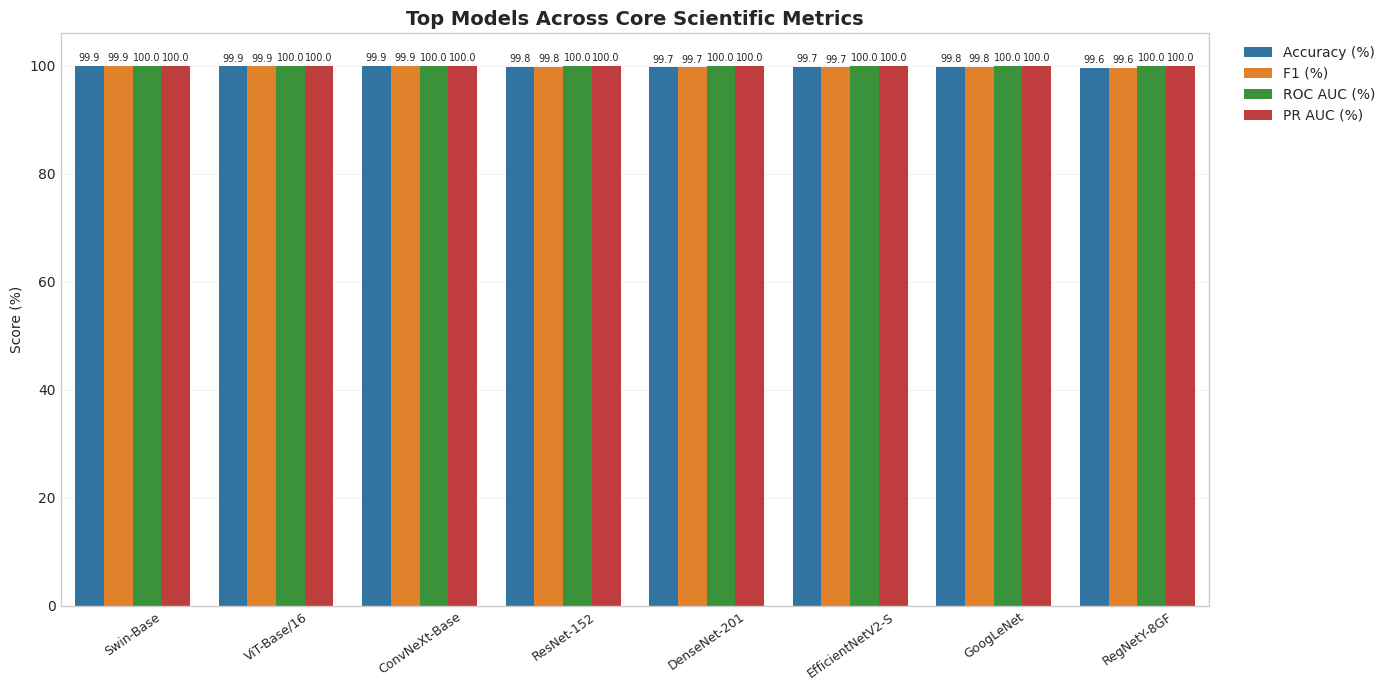

Saved: synthcifar_top_models_metric_bars.png


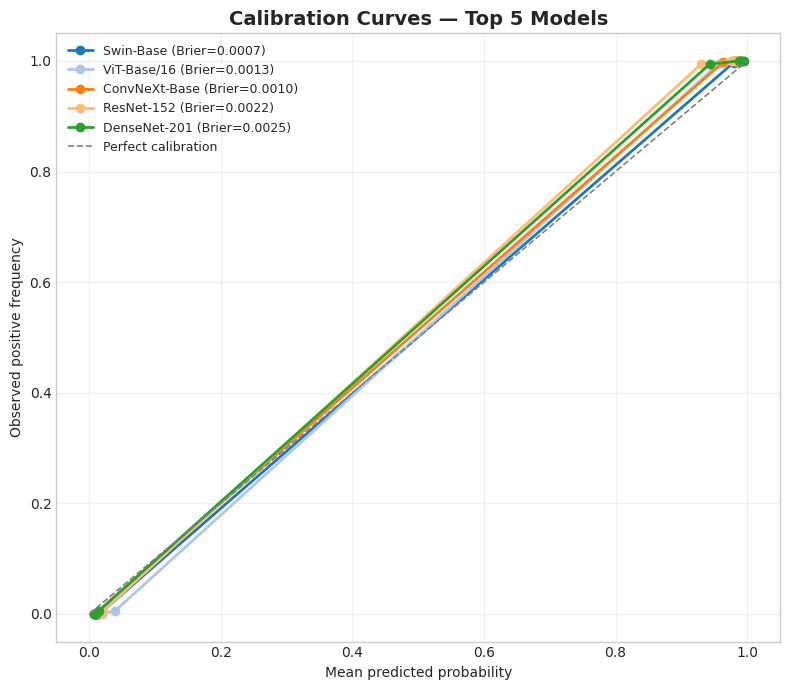

Saved: synthcifar_calibration_top5.png


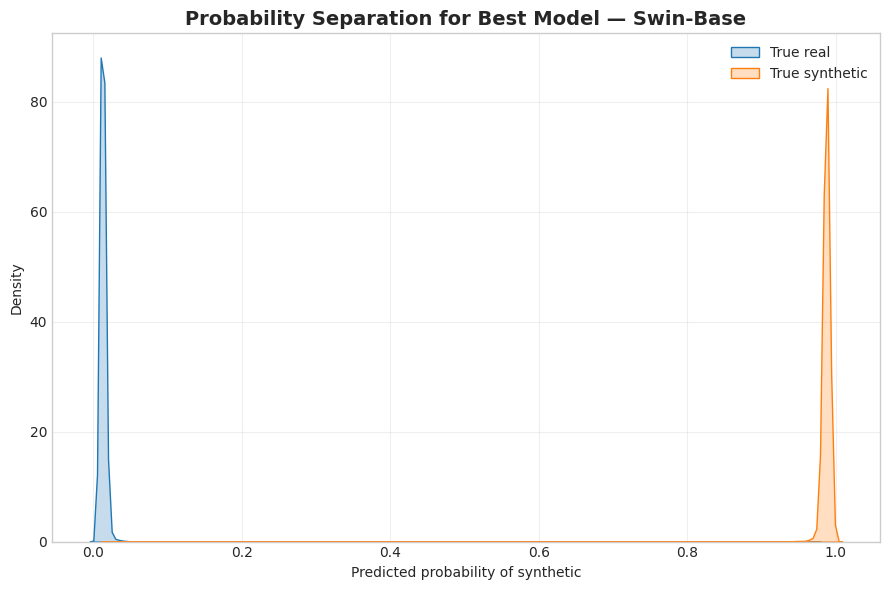

Saved: synthcifar_best_model_probability_separation.png


,Class,Precision (%),Recall / Sensitivity (%),Specificity (%),NPV (%),FPR (%),FNR (%),F1 Score (%),Support
0,real,99.93,99.96,99.93,99.96,0.07,0.04,99.95,10000
1,synthetic,99.96,99.93,99.96,99.93,0.04,0.07,99.94,10000


In [33]:
top8 = df.head(min(8, len(df))).copy()
plot_metrics = [
    "Accuracy (%)",
    # "Balanced Accuracy (%)",
    "F1 (%)",
    "ROC AUC (%)",
    "PR AUC (%)",
]
plot_long = top8.melt(
    id_vars=["Model"],
    value_vars=plot_metrics,
    var_name="Metric",
    value_name="Value",
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(data=plot_long, x="Model", y="Value", hue="Metric", ax=ax)

for container in ax.containers:
    labels = [
        f"{bar.get_height():.1f}" if np.isfinite(bar.get_height()) else ""
        for bar in container
    ]
    ax.bar_label(
        container,
        labels=labels,
        padding=2,
        fontsize=7,
        rotation=0
    )

ax.set_ylim(0, max(plot_long["Value"].max() + 6, 105))
ax.set_title("Top Models Across Core Scientific Metrics", fontsize=14, fontweight="bold")
ax.set_ylabel("Score (%)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=35, labelsize=9)
ax.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig("synthcifar_top_models_metric_bars.png", dpi=160, bbox_inches="tight")
plt.show()
print("Saved: synthcifar_top_models_metric_bars.png")

best_model_name = df.iloc[0]["Model"]
best_result = SYNTH_RESULTS[best_model_name]

fig, ax = plt.subplots(figsize=(8, 7))
for i, model_name in enumerate(top_models[:5]):
    calib_pred, calib_true = SYNTH_RESULTS[model_name]["calibration_curve"]
    brier = SYNTH_RESULTS[model_name]["brier_score"]
    ax.plot(calib_pred, calib_true, marker="o", linewidth=2, label=f"{model_name} (Brier={brier:.4f})", color=PALETTE[i])

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1.2, label="Perfect calibration")
ax.set_title("Calibration Curves — Top 5 Models", fontsize=14, fontweight="bold")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed positive frequency")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("synthcifar_calibration_top5.png", dpi=160, bbox_inches="tight")
plt.show()
print("Saved: synthcifar_calibration_top5.png")

labels = best_result["labels"]
pos_probs = best_result["positive_probs"]
true_is_pos = labels == POSITIVE_CLASS_INDEX

fig, ax = plt.subplots(figsize=(9, 6))
sns.kdeplot(pos_probs[~true_is_pos], fill=True, label="True real", ax=ax)
sns.kdeplot(pos_probs[true_is_pos], fill=True, label="True synthetic", ax=ax)
ax.set_title(f"Probability Separation for Best Model — {best_model_name}", fontsize=14, fontweight="bold")
ax.set_xlabel("Predicted probability of synthetic")
ax.set_ylabel("Density")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("synthcifar_best_model_probability_separation.png", dpi=160, bbox_inches="tight")
plt.show()
print("Saved: synthcifar_best_model_probability_separation.png")

display(
    best_result["per_class_metrics"].style.format({
        "Precision (%)": "{:.2f}",
        "Recall / Sensitivity (%)": "{:.2f}",
        "Specificity (%)": "{:.2f}",
        "NPV (%)": "{:.2f}",
        "FPR (%)": "{:.2f}",
        "FNR (%)": "{:.2f}",
        "F1 Score (%)": "{:.2f}",
    })
)


## 🧾 11 · Final Summary

The final text summary reports the strongest models under multiple perspectives while keeping the task definition explicit:

- **task:** binary classification on SynthCIFAR


In [27]:
print("=" * 92)
print("  SYNTHCIFAR BINARY BENCHMARK — SCIENTIFIC CLASSIFICATION SUMMARY")
print("=" * 92)

best_overall = df.iloc[0]
best_acc = df.sort_values("Accuracy (%)", ascending=False).iloc[0]
best_f1 = df.sort_values("F1 (%)", ascending=False).iloc[0]
best_auc = df.sort_values("ROC AUC (%)", ascending=False).iloc[0]
best_pr = df.sort_values("PR AUC (%)", ascending=False).iloc[0]
best_mcc = df.sort_values("MCC", ascending=False).iloc[0]
best_spec = df.sort_values("Specificity (%)", ascending=False).iloc[0]
best_cal = df.sort_values("Brier Score", ascending=True).iloc[0]

print(f"\nPositive class: {POSITIVE_CLASS_NAME}")
print(f"Train classes : {SYNTH_CLASSES}")
print(f"Test counts   : {test_counts}")

print(f"\n🥇 Best Overall (mean rank)  : {best_overall['Model']:20s}  Mean Rank={best_overall['Mean Rank']:.2f}")
print(f"🎯 Highest Accuracy          : {best_acc['Model']:20s}  {best_acc['Accuracy (%)']:.2f}%")
print(f"📌 Best F1       : {best_f1['Model']:20s}  {best_f1['F1 (%)']:.2f}%")
print(f"📈 Best ROC AUC              : {best_auc['Model']:20s}  {best_auc['ROC AUC (%)']:.2f}%")
print(f"🧲 Best PR AUC               : {best_pr['Model']:20s}  {best_pr['PR AUC (%)']:.2f}%")
print(f"🛡️ Best Specificity          : {best_spec['Model']:20s}  {best_spec['Specificity (%)']:.2f}%")
print(f"🤝 Best MCC                  : {best_mcc['Model']:20s}  {best_mcc['MCC']:.4f}")
print(f"🧪 Best Calibration (Brier)  : {best_cal['Model']:20s}  {best_cal['Brier Score']:.4f}")

print("\nFinal ranking table:")
print(df[[
    "Overall Rank",
    "Model",
    "Accuracy (%)",
    "Balanced Accuracy (%)",
    "Precision (%)",
    "Recall (%)",
    "Specificity (%)",
    "F1 (%)",
    "ROC AUC (%)",
    "PR AUC (%)",
    "MCC",
    "Cohen's Kappa",
    "Log Loss",
    "Brier Score",
    "Mean Rank",
]].to_string(index=False))

print(f"\nDetailed classification report for the best-ranked model ({best_model_name}):")
print(best_result["class_report"])

print("\nSaved artifacts:")
for fname in [
    "synthcifar_binary_scientific_report_metrics.csv",
    "synthcifar_confusion_matrices_all_models.png",
    "synthcifar_roc_curves_top_models.png",
    "synthcifar_pr_curves_top_models.png",
    "synthcifar_top_models_metric_bars.png",
    "synthcifar_calibration_top5.png",
    "synthcifar_best_model_probability_separation.png",
]:
    if Path(fname).exists():
        print(f"  ✅ {fname}")


  SYNTHCIFAR BINARY BENCHMARK — SCIENTIFIC CLASSIFICATION SUMMARY

Positive class: synthetic
Train classes : ['real', 'synthetic']
Test counts   : {'real': 10000, 'synthetic': 10000}

🥇 Best Overall (mean rank)  : Swin-Base             Mean Rank=1.40
🎯 Highest Accuracy          : Swin-Base             99.94%
📌 Best F1       : Swin-Base             99.94%
📈 Best ROC AUC              : Swin-Base             100.00%
🧲 Best PR AUC               : Swin-Base             100.00%
🛡️ Best Specificity          : EfficientNetV2-S      100.00%
🤝 Best MCC                  : Swin-Base             0.9989
🧪 Best Calibration (Brier)  : Swin-Base             0.0007

Final ranking table:
 Overall Rank            Model  Accuracy (%)  Balanced Accuracy (%)  Precision (%)  Recall (%)  Specificity (%)  F1 (%)  ROC AUC (%)  PR AUC (%)    MCC  Cohen's Kappa  Log Loss  Brier Score  Mean Rank
            1        Swin-Base         99.94                  99.94          99.96       99.93            99.96   99.94  